# Week 7 Phase 5 — manual Keyhole morphology and continuous physical proxies

This notebook asks whether one already-defined physical scalar can faithfully represent Ioan's manual cavity-based Keyhole regime. It is a target-formulation analysis, not a classifier, active-learning, or level-set experiment.

## 1. Scope and Phase 4 parent commit

**What are we doing?** We establish the exact parent commit, branch, paths, and analysis mode.

**Why are we doing it?** A target-formulation result is only reproducible if its repository parent and hard stop are explicit.

**What question does it answer?** Did Phase 5 really start from the committed Phase 4 state?

**What would be misleading?** Treating a later main-branch state or an unrecorded worktree as the scientific parent.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
OUT = ROOT / "outputs" / "week7_05_keyhole_physical_proxy_analysis"
preflight = json.loads((OUT / "phase5_preflight.json").read_text(encoding="utf-8"))
pd.DataFrame([preflight])

,phase5_branch,phase5_parent_sha,working_tree_status_at_preflight,checked_at_utc
0,codex/week7-phase5-keyhole-physical-proxy-anal...,5b7004017cadc5ecd0eb128f2031f9148ed70900,?? outputs/week7_05_keyhole_physical_proxy_ana...,2026-08-11T12:48:12.302396+00:00


**What did we observe?** The branch is `codex/week7-phase5-keyhole-physical-proxy-analysis` at exact Phase 4 commit `5b7004017cadc5ecd0eb128f2031f9148ed70900`.

**What does it mean?** All Phase 5 artifacts share one committed Phase 4 parent.

**Does it support a continuous proxy?** This prevents repository drift from masquerading as proxy evidence.

**What remains uncertain?** Phase 5 itself remains intentionally uncommitted for review.

## 2. Dataset provenance and accepted monitor restoration audit

**What are we doing?** We inspect the exact pinned-to-current Hugging Face tree diff.

**Why are we doing it?** The accepted PR restored old-data monitors, but primary new-data science must remain unchanged.

**What question does it answer?** Were the only changes 55 pairs of old-data monitor files?

**What would be misleading?** Merely trusting a commit message without checking every changed path and registry partition.

In [2]:
dataset_audit = json.loads((OUT / "dataset_revision_audit.json").read_text(encoding="utf-8"))
revision_diff = pd.read_csv(OUT / "current_revision_diff_audit.csv")
display(pd.DataFrame([dataset_audit]))
display(revision_diff.groupby(["status", "registry_partition", "file_name"]).size().rename("path_count").reset_index())

,dataset_repo_id,pinned_scientific_revision,current_main_revision,current_commit_subject,changed_path_count,changed_experiment_count,status_counts,file_name_counts,partition_counts,new_data_changed_path_count,label_or_geometry_changed_path_count,accepted_old_data_monitor_restoration_only,new_data_scientific_content_unchanged_by_git_tree_diff,evidence_boundary,audited_at_utc
0,ioandanielc/sph_v2,d69dac5bda8b622bc0de316b112815c6056c06ec,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8,Restore missing old-data monitor streams (#1),110,55,{'A': 110},"{'kinetic-energy_melt.dat': 55, 'time.dat': 55}",{'old-data-local': 55},0,0,True,True,Git tree comparison proves that every path out...,2026-08-11T12:48:17.803560+00:00


,status,registry_partition,file_name,path_count
0,A,old-data-local,kinetic-energy_melt.dat,55
1,A,old-data-local,time.dat,55


**What did we observe?** Exactly 110 added paths map to 55 `old-data-local` experiments: 55 `time.dat` and 55 `kinetic-energy_melt.dat`. No new-data, label, or geometry path changed.

**What does it mean?** Current repository provenance can be recorded while the pinned new-data scalar/label content remains the scientific source.

**Does it support a continuous proxy?** The restoration cannot create the new-data G3/Keyhole association because none of those paths changed.

**What remains uncertain?** Future changes to Hugging Face main would require a fresh audit.

## 3. Ioan's manual Keyhole-label definition

**What are we doing?** We record the supervisor's exact label-provenance statement and its evidence boundary.

**Why are we doing it?** The interpretation changes fundamentally if labels are morphology judgements rather than a known numerical threshold.

**What question does it answer?** What visual rule informed the Keyhole annotations?

**What would be misleading?** Claiming that Ioan labelled with G3, depth, or another deterministic scalar.

In [3]:
display(Markdown((OUT / "label_provenance.md").read_text(encoding="utf-8")))

# Keyhole label provenance

Supervisor statement (Ioan):

> I did it by hand. So almost qualitatively. Usually the existence of cavities directly under the meltpool determined my decision for keyhole.

Phase 5 interpretation:

- The frame labels were assigned manually and qualitatively.
- Cavities directly beneath the melt pool were the usual visual cue for Keyhole.
- Ioan did not report a deterministic scalar-monitor threshold as the labelling rule.
- Physical scalar associations are plausible because cavity morphology and melt geometry are related, but the analysis is associational rather than causal.
- The source labels and the validated Phase 1 `has_keyhole` semantics are unchanged.
- Discordant-case notes never relabel an experiment and are not new ground truth.


**What did we observe?** Ioan described manual, almost qualitative labelling, usually guided by cavities directly under the melt pool.

**What does it mean?** A strong scalar association is an empirical physical consistency result, not circular recovery of a reported threshold.

**Does it support a continuous proxy?** It makes a continuous candidate scientifically interesting while preserving the morphology label as reference.

**What remains uncertain?** Manual visual decisions can still be physically coupled to penetration and aspect ratio.

## 4. Experiment-level label composition

**What are we doing?** We audit all 165 new-data experiments using validated Phase 1 fields.

**Why are we doing it?** `has_keyhole=False` must not silently be equated with Conduction before checking frame composition.

**What question does it answer?** How many positives, negatives, transient, persistent, repeated, and timing-defined cases exist?

**What would be misleading?** Dropping the target-ineligible row or regenerating label semantics with a new rule.

In [4]:
labels = pd.read_csv(OUT / "experiment_level_label_audit.csv")
composition = {
    "total": len(labels),
    "Keyhole-positive": int(labels.has_keyhole.astype(bool).sum()),
    "Keyhole-negative": int((~labels.has_keyhole.astype(bool)).sum()),
    "negative without Conduction": int(labels.keyhole_negative_without_conduction.astype(bool).sum()),
    "transient": int(labels.keyhole_transient_by_sequence.astype(bool).sum()),
    "persistent": int(labels.keyhole_persistent_to_last_physical_frame.astype(bool).sum()),
    "repeated": int(labels.repeated_keyhole_episodes.astype(bool).sum()),
}
display(pd.Series(composition, name="experiment_count").to_frame())
display(labels.loc[labels.has_keyhole.astype(bool), "keyhole_timing_relative_to_T0"].value_counts().rename("count").to_frame())

,experiment_count
total,165
Keyhole-positive,63
Keyhole-negative,102
negative without Conduction,0
transient,30
persistent,33
repeated,16


,count
keyhole_timing_relative_to_T0,
spans_multiple_T0_regions,41
before_T0,22


**What did we observe?** There are 63 Keyhole-positive and 102 negative experiments; all 102 negatives contain Conduction. Keyhole positives split into 30 transient and 33 persistent cases, including 16 repeated episodes.

**What does it mean?** The binary experiment label is well defined without relabelling, and important temporal subgroups are large enough to audit.

**Does it support a continuous proxy?** A candidate that works only for persistent cases can be detected rather than hidden in one aggregate metric.

**What remains uncertain?** Only saved frame labels are observable; events between saved frames remain outside the label evidence.

## 5. Continuous candidate definitions and readiness

**What are we doing?** We list the eight predefined scalars and their machine-derived availability.

**Why are we doing it?** Candidate definitions and missingness must be fixed before looking at separation.

**What question does it answer?** Which physical quantities are compared, and for how many simulations are they valid?

**What would be misleading?** Inventing a ratio after seeing labels or replacing unavailable values with zero/interpolation.

In [5]:
definitions = pd.read_csv(OUT / "physical_proxy_candidate_definitions.csv")
display(definitions[["candidate_id", "candidate_name", "unit", "definition", "ready_n", "missing_n", "source"]])

,candidate_id,candidate_name,unit,definition,ready_n,missing_n,source
0,T0_depth,T0 penetration depth,um,Median penetration depth in the unchanged Phas...,164,1,corrected Phase 2 T0_depth_um
1,max_depth,Maximum penetration depth,um,Maximum valid penetration depth over the compl...,164,1,corrected Phase 2 max_depth_um
2,G3,G3 persistent depth,um,Maximum trailing 50 um rolling-median depth in...,164,1,corrected Phase 2 G3_persistent_depth_um; unch...
3,R3,R3 persistent aspect ratio,dimensionless,Maximum trailing 50 um rolling-median depth/wi...,164,1,corrected Phase 2 R3_persistent_depth_width_ra...
4,T0_width,T0 width,um,Median transverse melt-pool width in the uncha...,164,1,corrected Phase 2 T0_width_um
5,T0_total_height,T0 total height,um,Median total vertical melt height in the uncha...,164,1,corrected Phase 2 T0_total_height_um
6,T0_kinetic_energy,T0 kinetic energy,nJ,Median whole-domain liquid-particle kinetic en...,164,1,corrected Phase 2 T0_kinetic_energy_nJ
7,R0,R0 T0 aspect ratio,dimensionless,"T0 penetration depth divided by T0 width, a pr...",164,1,"predefined Week 6 R0 family, evaluated from co..."


**What did we observe?** All eight candidates are machine-ready for 164/165 experiments. The missing experiment stays in the population reference with unavailable scalar values.

**What does it mean?** Candidate comparisons have common missingness here, while readiness remains explicit.

**Does it support a continuous proxy?** G3/R3/max depth/T0 retain their earlier definitions; R0 is the predefined T0 depth/width diagnostic.

**What remains uncertain?** R0 couples two scalars and is not as direct a dimensional level-set quantity as G3.

## 6. Keyhole versus non-Keyhole descriptive distributions

**What are we doing?** We show distributions and ECDFs for T0 depth, max depth, G3, and R3 without hiding overlap.

**Why are we doing it?** Medians alone can conceal tails, multimodality, and exceptions.

**What question does it answer?** Do manual Keyhole and negative simulations occupy visibly different physical ranges?

**What would be misleading?** Showing only a fitted separator or a truncated axis that hides discordant cases.

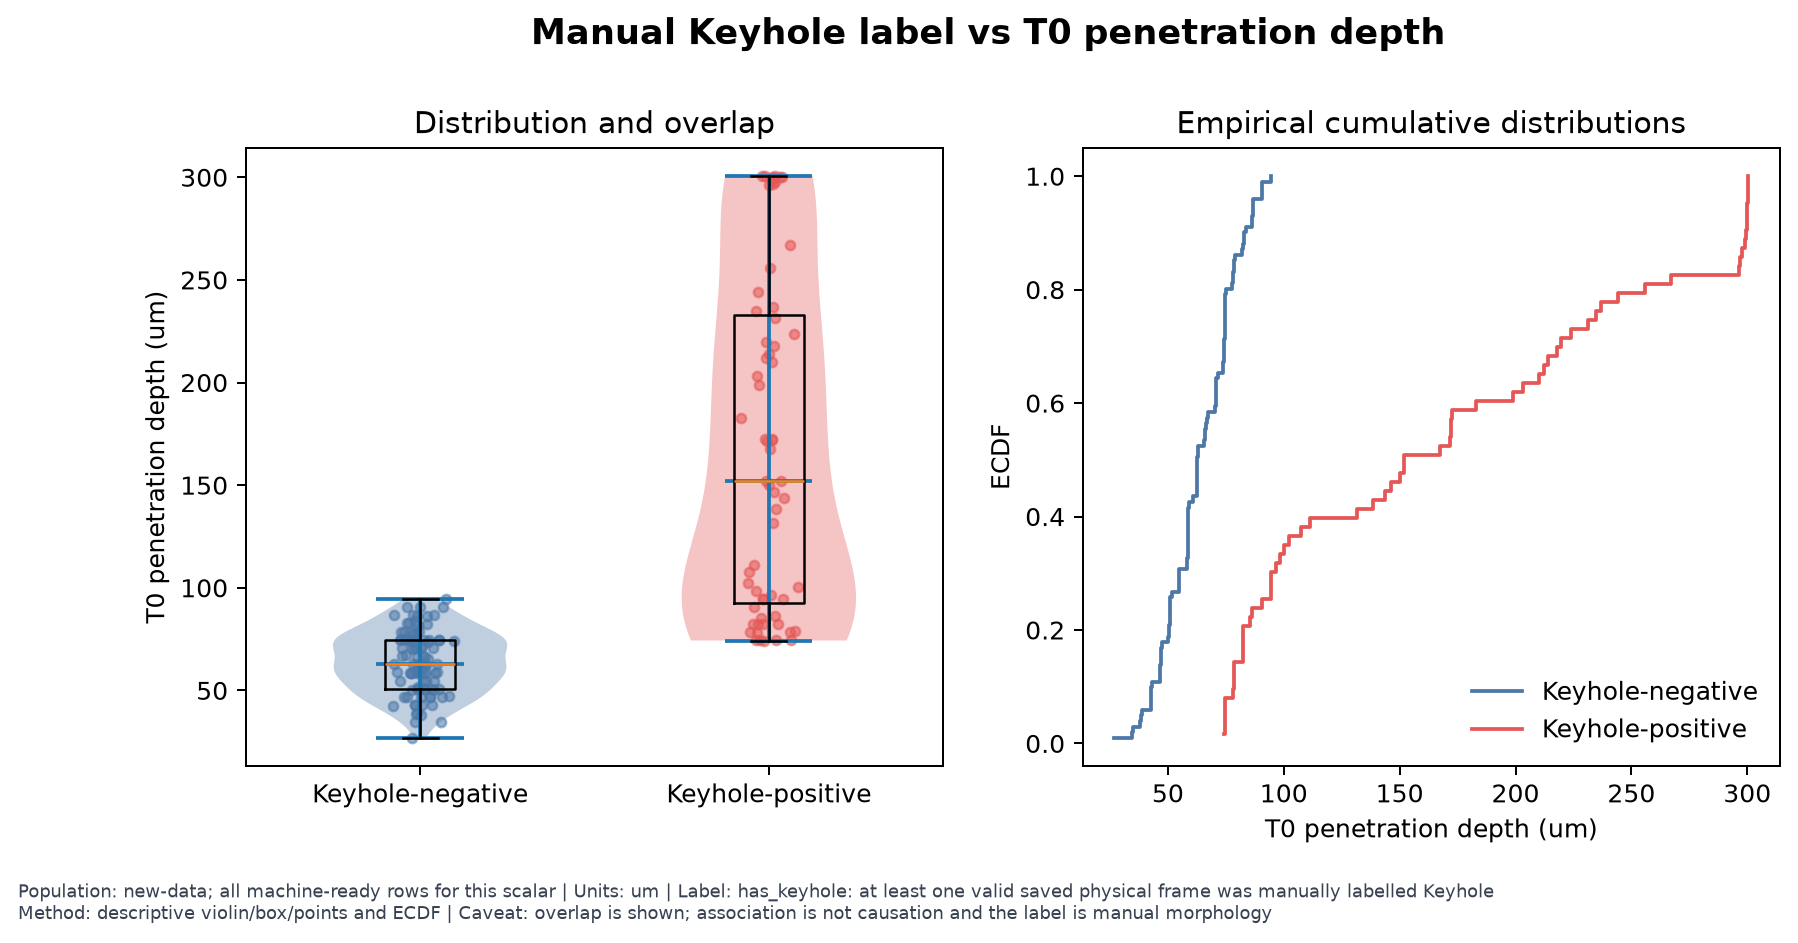

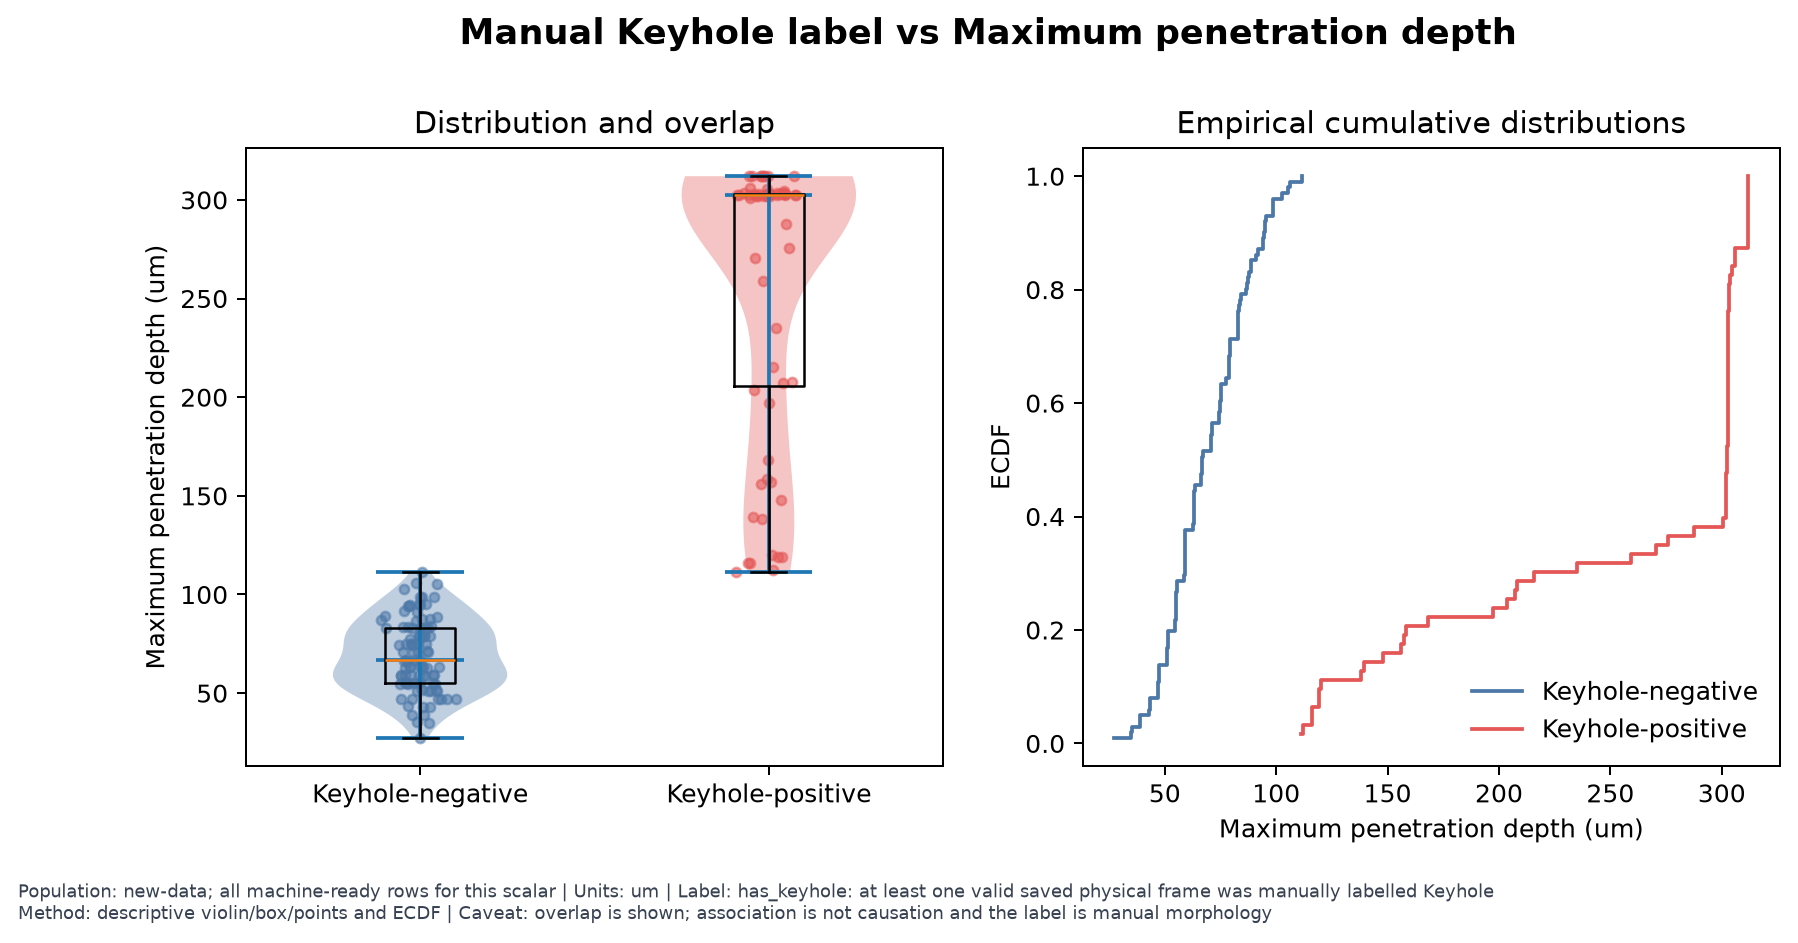

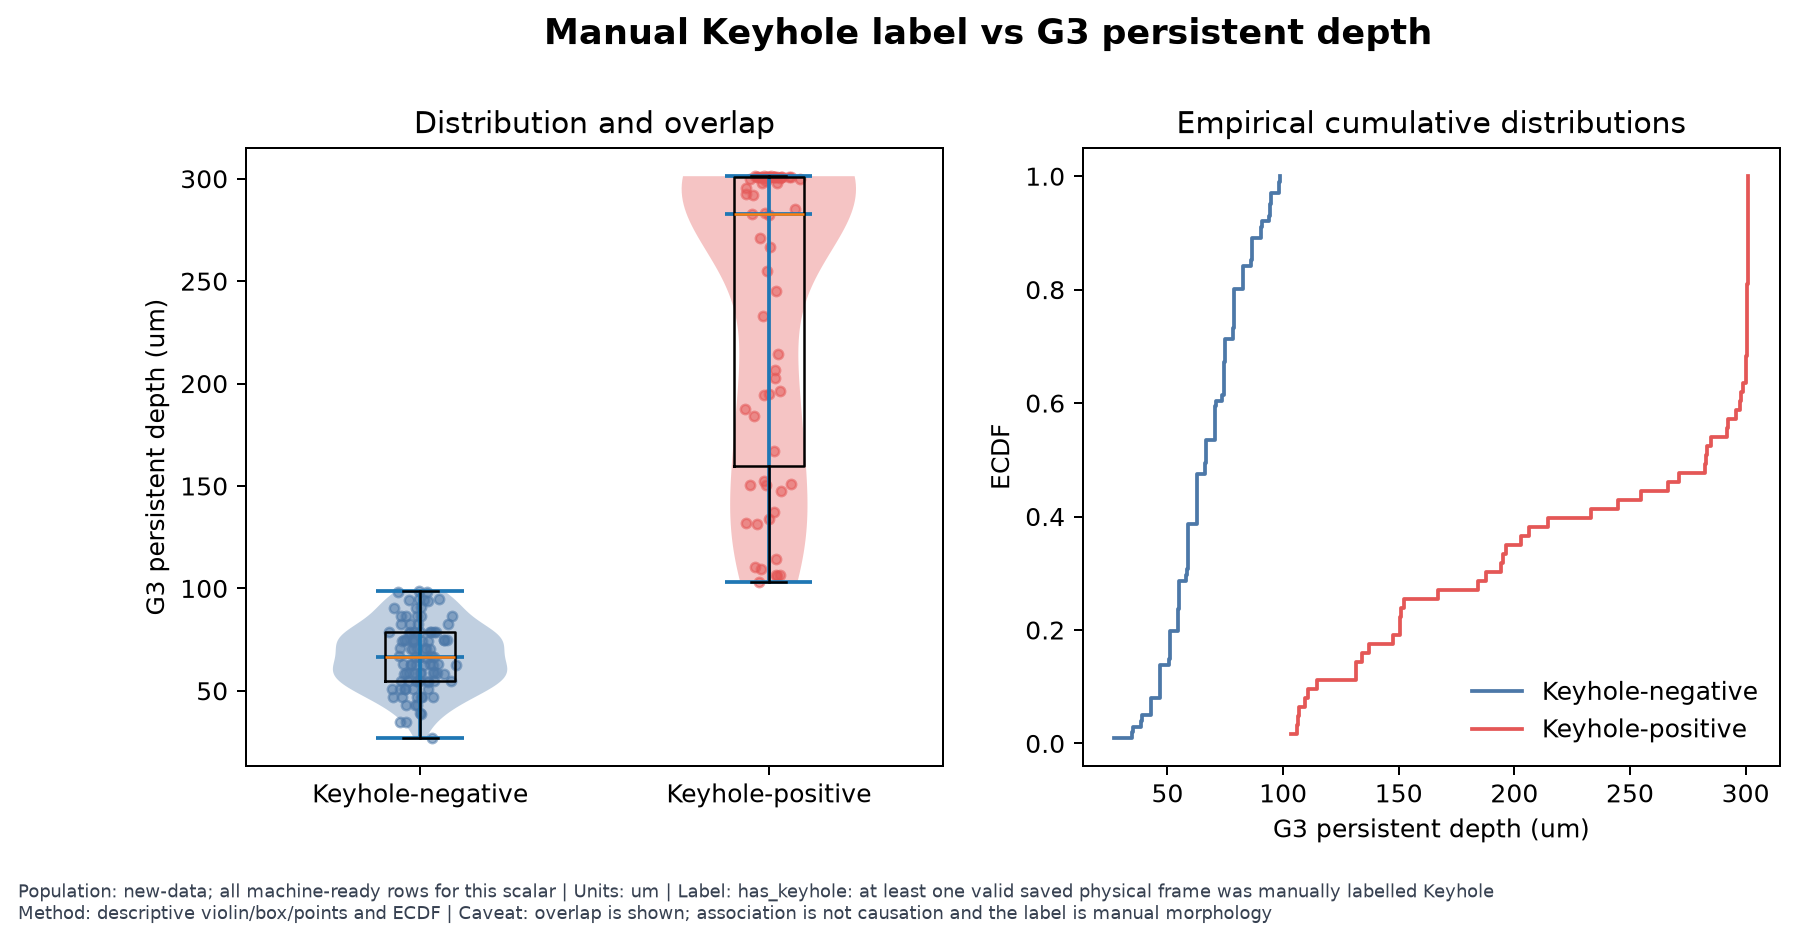

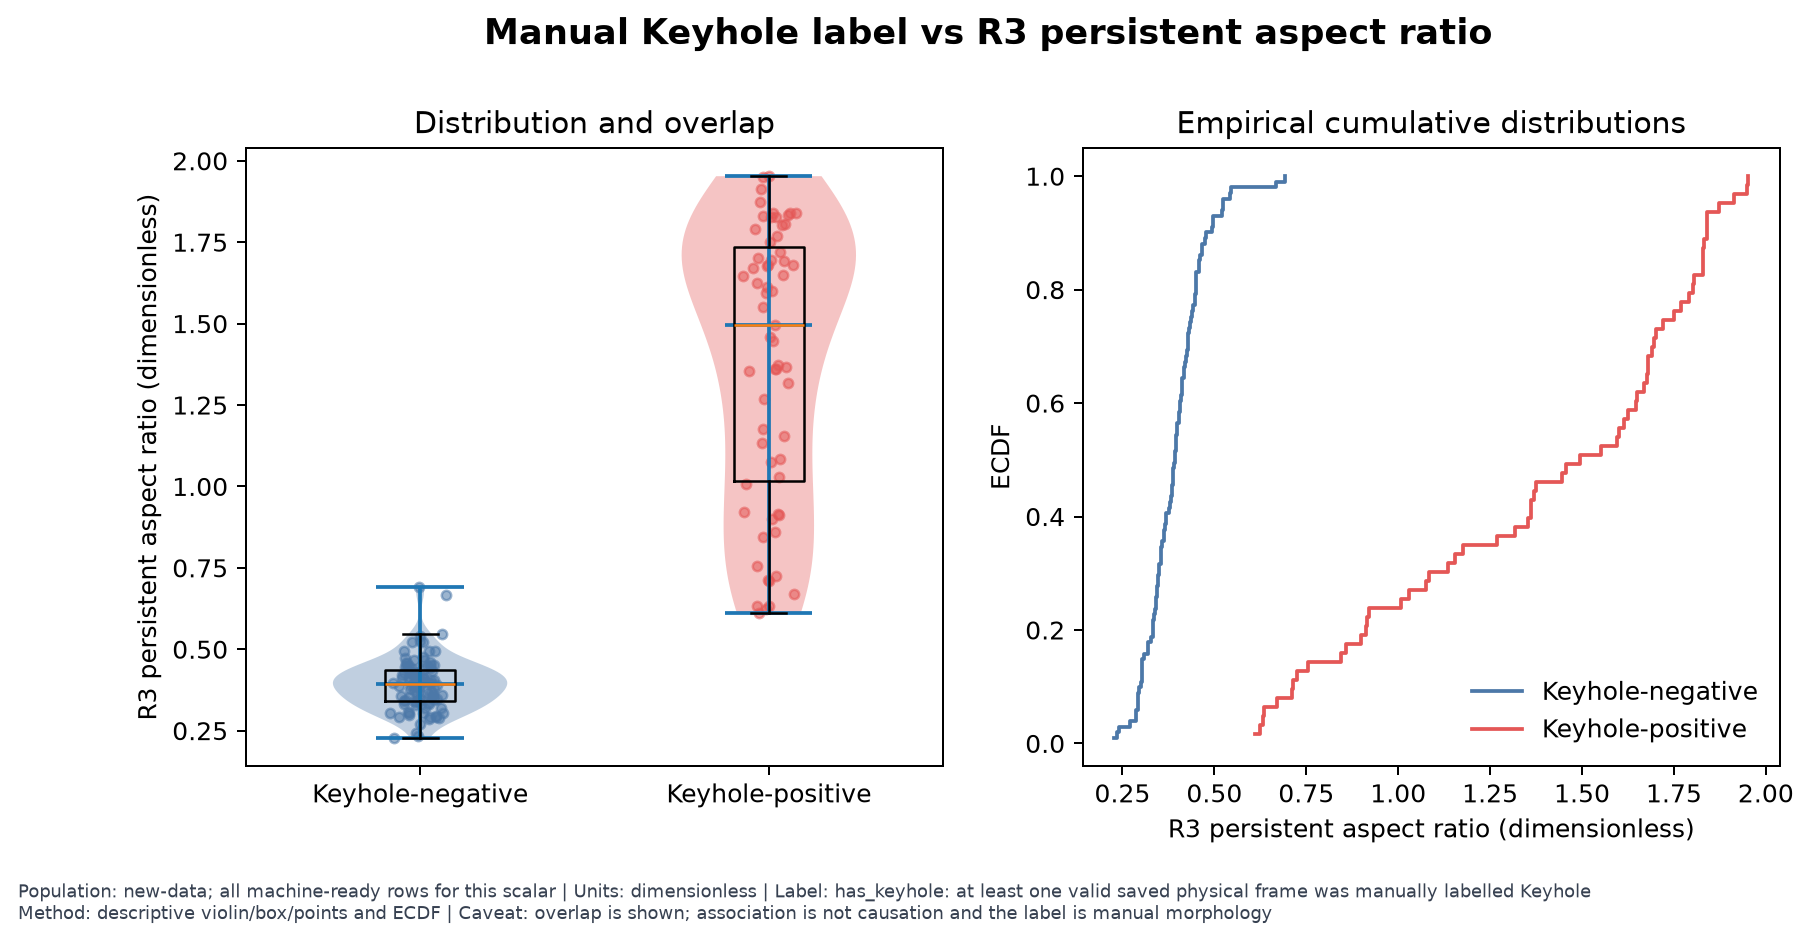

In [6]:
for filename in [
    "01_T0_depth_keyhole_distribution.png",
    "02_max_depth_keyhole_distribution.png",
    "03_G3_keyhole_distribution.png",
    "04_R3_keyhole_distribution.png",
]:
    display(Image(filename=str(OUT / "figures" / filename)))

**What did we observe?** G3 exhibits complete observed separation; max depth and R3 show only tiny overlap, while T0 depth shows visibly more overlap.

**What does it mean?** Persistence-aware or whole-track depth information aligns more closely with cavity-based morphology than an ordinary late-active median.

**Does it support a continuous proxy?** The descriptive view strongly motivates formal rank and held-out threshold tests.

**What remains uncertain?** Observed separation in one finite design is not a universal physical law.

## 7. Effect sizes and bootstrap intervals

**What are we doing?** We quantify median shifts, rank-biserial effects, Mann–Whitney tests, and simulation-level bootstrap intervals.

**Why are we doing it?** Practical separation and uncertainty matter more than a small p-value alone.

**What question does it answer?** How large and directionally consistent are group differences?

**What would be misleading?** Equating statistical significance with a faithful proxy.

In [7]:
effects = pd.read_csv(OUT / "physical_proxy_effect_sizes.csv")
display(effects.sort_values("rank_biserial_effect_size", ascending=False)[[
    "candidate_id", "median_difference_keyhole_minus_negative", "median_difference_ci_low",
    "median_difference_ci_high", "rank_biserial_effect_size", "rank_biserial_ci_low",
    "rank_biserial_ci_high", "mann_whitney_two_sided_pvalue"
]])

,candidate_id,median_difference_keyhole_minus_negative,median_difference_ci_low,median_difference_ci_high,rank_biserial_effect_size,rank_biserial_ci_low,rank_biserial_ci_high,mann_whitney_two_sided_pvalue
2,G3,216.474790,143.613378,234.191517,1.000000,1.000000,1.000000,5.657381e-27
1,max_depth,235.572700,224.591174,239.594861,0.999686,0.998114,1.000000,5.868638e-27
3,R3,1.101678,0.930965,1.273997,0.997171,0.990885,1.000000,7.865654e-27
7,R0,0.647171,0.338346,0.815962,0.921735,0.853835,0.975169,3.674671e-23
0,T0_depth,89.299360,44.867160,140.560100,0.915449,0.859500,0.959767,7.214747e-23
5,T0_total_height,93.337160,37.630870,136.385515,0.813296,0.718050,0.896283,2.208660e-18
6,T0_kinetic_energy,2.133201,1.737025,2.649350,0.799151,0.703591,0.882768,8.402362e-18
4,T0_width,-11.603500,-25.772025,7.882630,-0.084708,-0.266384,0.106082,3.631224e-01


**What did we observe?** G3 has the largest rank effect (1.0000); 5,000 simulation-level resamples quantify uncertainty in the full run.

**What does it mean?** The group shift is large in both magnitude and rank ordering.

**Does it support a continuous proxy?** This is necessary evidence for a continuous proxy, but threshold generalization remains separate.

**What remains uncertain?** Bootstrap intervals describe this sampled design and label set, not unseen process regimes.

## 8. ROC AUC and PR AUC comparison

**What are we doing?** We compare rank separation with both ROC AUC and average precision, preserving raw physical direction.

**Why are we doing it?** The 63/165 Keyhole prevalence makes accuracy alone insufficient.

**What question does it answer?** Which scalar most consistently ranks manual Keyhole above negatives?

**What would be misleading?** Quietly flipping a sign or claiming a high AUC supplies a stable threshold.

,candidate_id,n,physical_direction,direction_adjusted_roc_auc,direction_adjusted_roc_auc_ci_low,direction_adjusted_roc_auc_ci_high,direction_adjusted_average_precision,direction_adjusted_average_precision_ci_low,direction_adjusted_average_precision_ci_high
0,G3,164,higher_is_more_keyhole_like,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,max_depth,164,higher_is_more_keyhole_like,0.999843,0.999057,1.000000,0.999752,0.998557,1.000000
2,R3,164,higher_is_more_keyhole_like,0.998586,0.995442,1.000000,0.997735,0.992875,1.000000
3,R0,164,higher_is_more_keyhole_like,0.960868,0.925350,0.987431,0.957640,0.923480,0.984344
4,T0_depth,164,higher_is_more_keyhole_like,0.957724,0.929907,0.979884,0.943431,0.909173,0.972137
5,T0_total_height,164,higher_is_more_keyhole_like,0.906648,0.857929,0.947988,0.893849,0.842107,0.939891
6,T0_kinetic_energy,164,higher_is_more_keyhole_like,0.899576,0.850228,0.941694,0.851775,0.780917,0.914751
7,T0_width,164,lower_is_more_keyhole_like,0.542354,0.448998,0.633671,0.413738,0.360253,0.511149


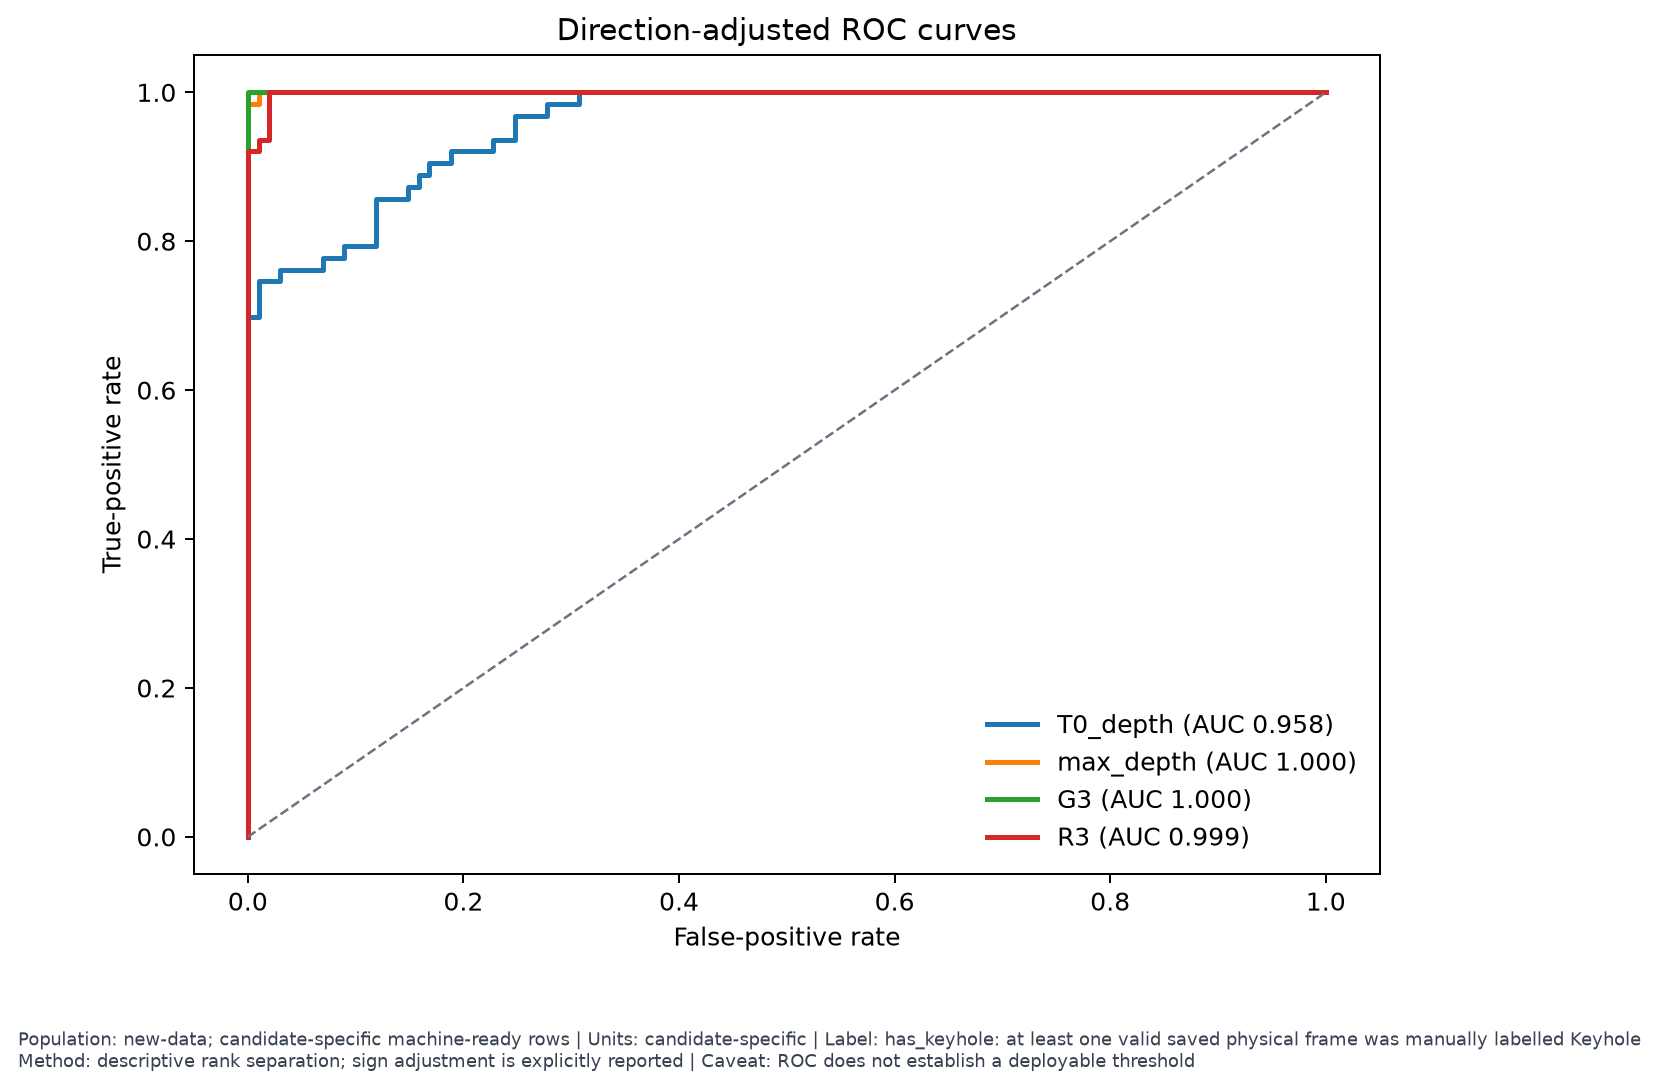

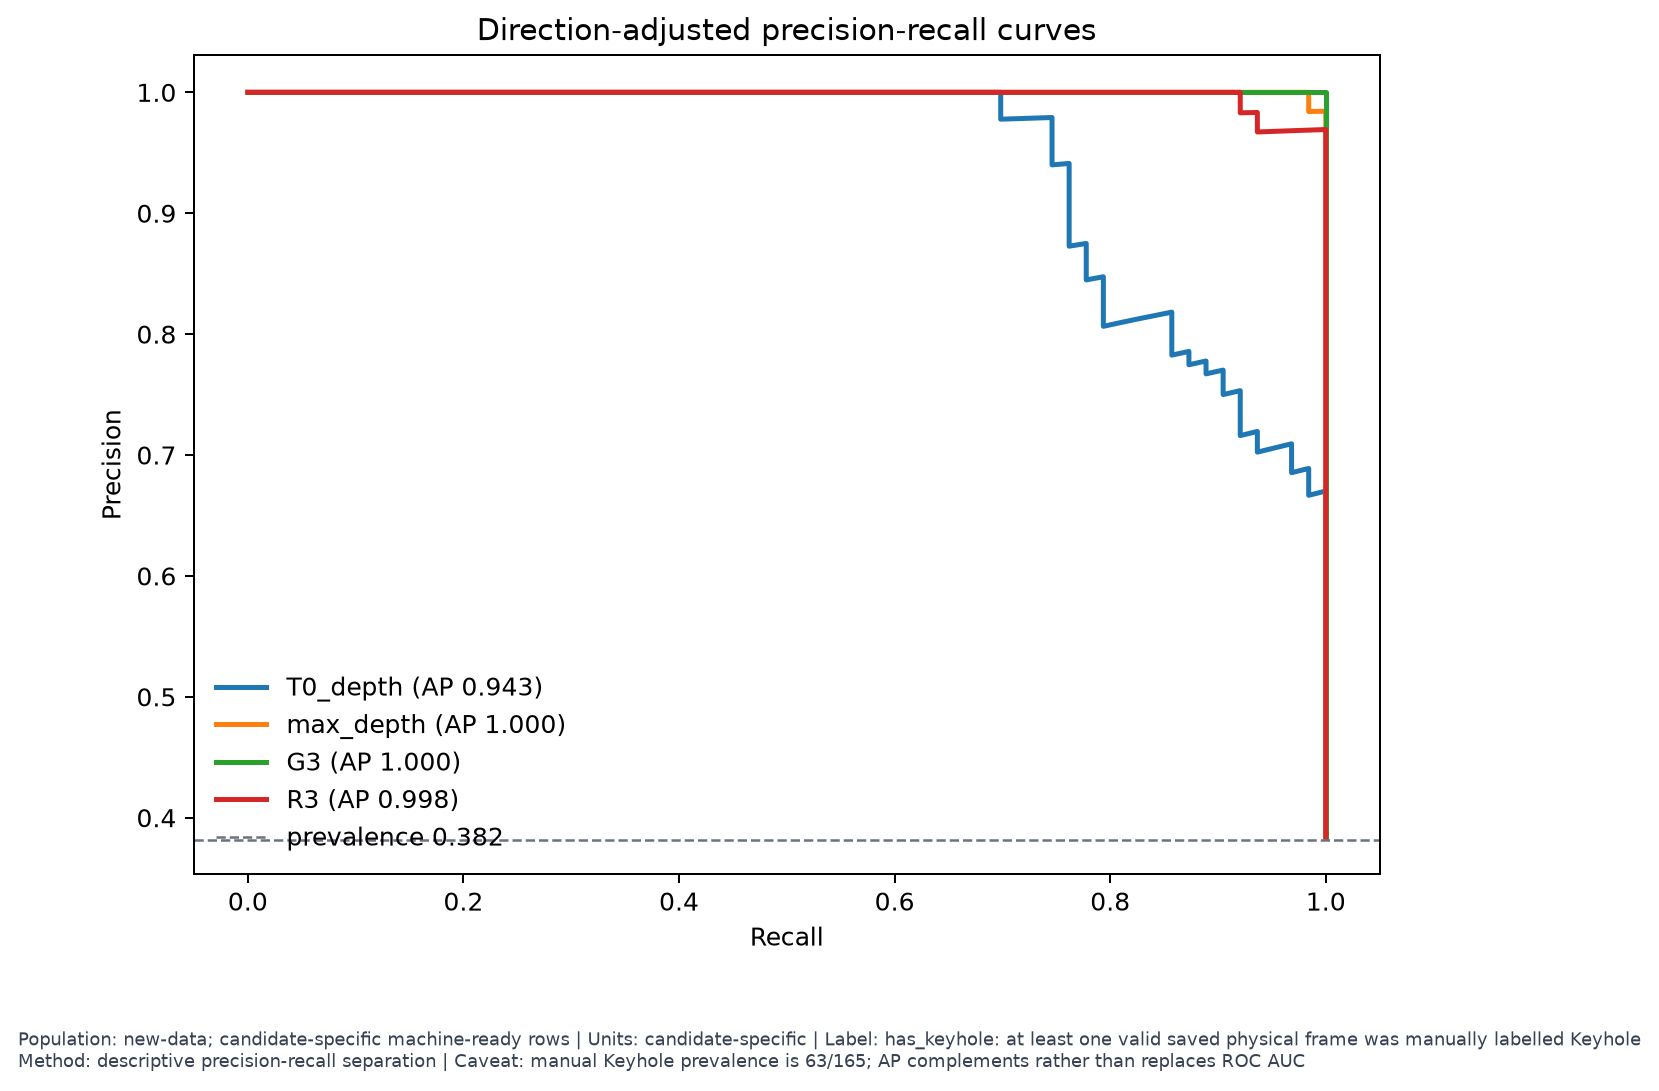

In [8]:
separation = pd.read_csv(OUT / "physical_proxy_univariate_separation.csv")
display(separation[["candidate_id", "n", "physical_direction", "direction_adjusted_roc_auc",
                    "direction_adjusted_roc_auc_ci_low", "direction_adjusted_roc_auc_ci_high",
                    "direction_adjusted_average_precision", "direction_adjusted_average_precision_ci_low",
                    "direction_adjusted_average_precision_ci_high"]])
display(Image(filename=str(OUT / "figures" / "05_main_candidate_roc_curves.png")))
display(Image(filename=str(OUT / "figures" / "06_main_candidate_precision_recall_curves.png")))

**What did we observe?** G3 leads both ROC AUC (1.0000) and average precision (1.0000).

**What does it mean?** G3 perfectly ranks the available new-data positives above negatives in this dataset.

**Does it support a continuous proxy?** This is exceptionally strong univariate separation with class-imbalance context.

**What remains uncertain?** Rank perfection does not by itself establish that a fold-trained cutoff will handle boundary cases.

## 9. Fair paired AUC comparisons

**What are we doing?** We compare specified candidate pairs on the same simulations with paired stratified bootstrap resampling.

**Why are we doing it?** Separate candidate populations or independent intervals can give unfair delta claims.

**What question does it answer?** Do max depth, G3, or R3 materially improve over T0 depth?

**What would be misleading?** Calling a tiny point-estimate difference material without common rows and a paired interval.

In [9]:
paired = pd.read_csv(OUT / "physical_proxy_pairwise_auc_comparison.csv")
display(paired[["baseline_candidate", "comparator_candidate", "common_complete_n",
                "delta_roc_auc_comparator_minus_baseline", "delta_roc_auc_ci_low",
                "delta_roc_auc_ci_high", "material_improvement"]])

,baseline_candidate,comparator_candidate,common_complete_n,delta_roc_auc_comparator_minus_baseline,delta_roc_auc_ci_low,delta_roc_auc_ci_high,material_improvement
0,T0_depth,max_depth,164,0.042118,2.058777e-02,7.134999e-02,True
1,T0_depth,G3,164,0.042276,2.011630e-02,7.056420e-02,True
2,T0_depth,R3,164,0.040861,1.885903e-02,6.931086e-02,True
3,max_depth,G3,164,0.000157,-1.110223e-16,9.429514e-04,False
4,max_depth,R3,164,-0.001257,-4.400440e-03,1.110223e-16,False
5,G3,R3,164,-0.001414,-4.714757e-03,0.000000e+00,False


**What did we observe?** G3 improves on T0 depth by paired AUC Δ=0.0423 (95% CI 0.0201 to 0.0706); the predeclared material-improvement rule is `True`.

**What does it mean?** The gain over T0 depth is not a missingness artifact.

**Does it support a continuous proxy?** Transient/persistent-sensitive depth quantities materially outperform the ordinary T0 median in rank separation.

**What remains uncertain?** G3, max depth, and R3 are so strong that their small pairwise differences are harder to distinguish reliably.

## 10. Leakage-free scalar threshold cross-validation

**What are we doing?** For every held-out simulation, training rows alone select direction and threshold by balanced accuracy.

**Why are we doing it?** A continuous level-set proxy should admit a simple rule that generalizes, not only rank well in-sample.

**What question does it answer?** Can a single scalar threshold predict the held-out manual label?

**What would be misleading?** Reporting the full-data optimum cutoff as predictive performance.

In [10]:
cv = pd.read_csv(OUT / "physical_proxy_threshold_cv_summary.csv")
stability = pd.read_csv(OUT / "physical_proxy_threshold_stability.csv")
display(cv[["candidate_id", "balanced_accuracy", "sensitivity_keyhole_recall", "specificity",
            "precision", "f1", "false_positive", "false_negative",
            "full_data_descriptive_threshold", "full_data_threshold_is_predictive_performance"]])
display(stability[["candidate_id", "majority_direction", "majority_direction_fraction",
                   "threshold_median", "threshold_iqr_over_candidate_iqr", "stability_class"]])

,candidate_id,balanced_accuracy,sensitivity_keyhole_recall,specificity,precision,f1,false_positive,false_negative,full_data_descriptive_threshold,full_data_threshold_is_predictive_performance
0,G3,1.000000,1.000000,1.000000,1.000000,1.000000,0,0,100.958763,False
1,R3,0.990099,1.000000,0.980198,0.969231,0.984375,2,0,0.578215,False
2,max_depth,0.987113,0.984127,0.990099,0.984127,0.984127,1,1,108.601000,False
3,R0,0.913720,0.857143,0.970297,0.947368,0.900000,3,9,0.518533,False
4,T0_kinetic_energy,0.820682,0.888889,0.752475,0.691358,0.777778,25,7,3.366769,False
5,T0_depth,0.778956,0.746032,0.811881,0.712121,0.728682,19,16,82.415067,False
6,T0_total_height,0.765991,0.650794,0.881188,0.773585,0.706897,12,22,112.911555,False
7,T0_width,0.566871,0.539683,0.594059,0.453333,0.492754,41,29,159.259077,False


,candidate_id,majority_direction,majority_direction_fraction,threshold_median,threshold_iqr_over_candidate_iqr,stability_class
0,T0_depth,higher,1.0,82.415067,0.000000,stable
1,max_depth,higher,1.0,108.601000,0.000000,stable
2,G3,higher,1.0,100.958763,0.000000,stable
3,R3,higher,1.0,0.578215,0.000000,stable
4,T0_width,lower,1.0,159.259077,0.000000,stable
5,T0_total_height,higher,1.0,126.053505,0.351332,stable
6,T0_kinetic_energy,higher,1.0,3.366769,0.000000,stable
7,R0,higher,1.0,0.518533,0.000000,stable


**What did we observe?** G3 achieves held-out balanced accuracy 1.0000, sensitivity 1.0000, and specificity 1.0000; its threshold class is `stable`.

**What does it mean?** The observed G3 gap is wide enough that fold-trained thresholds classify every held-out ready simulation correctly.

**Does it support a continuous proxy?** This is the strongest evidence that G3 is more than a descriptive correlate.

**What remains uncertain?** External designs may shrink or shift the threshold gap; Phase 5 does not test out-of-distribution generalization.

## 11. T0 timing versus brief Keyhole events

**What are we doing?** We reuse validated timing groups to compare candidate values and held-out sensitivity.

**Why are we doing it?** A late-active T0 median can miss a morphology event that occurs only before T0.

**What question does it answer?** Does max depth or G3 handle before-T0 Keyhole better than T0 depth?

**What would be misleading?** Inventing exact frame-monitor alignment beyond the saved Phase 2 timing fields.

,candidate_id,group,n,median,cv_sensitivity_within_positive_group
0,T0_depth,before_T0,22,82.557460,0.272727
1,T0_depth,no_Keyhole,101,62.753340,NaN
2,T0_depth,spans_multiple_T0_regions,41,214.145700,1.000000
3,max_depth,before_T0,22,156.611100,0.954545
4,max_depth,no_Keyhole,101,66.837000,NaN
5,max_depth,spans_multiple_T0_regions,41,302.676700,1.000000
6,G3,before_T0,22,142.280025,1.000000
7,G3,no_Keyhole,101,66.523210,NaN
8,G3,spans_multiple_T0_regions,41,300.319400,1.000000
9,R3,before_T0,22,0.905593,1.000000


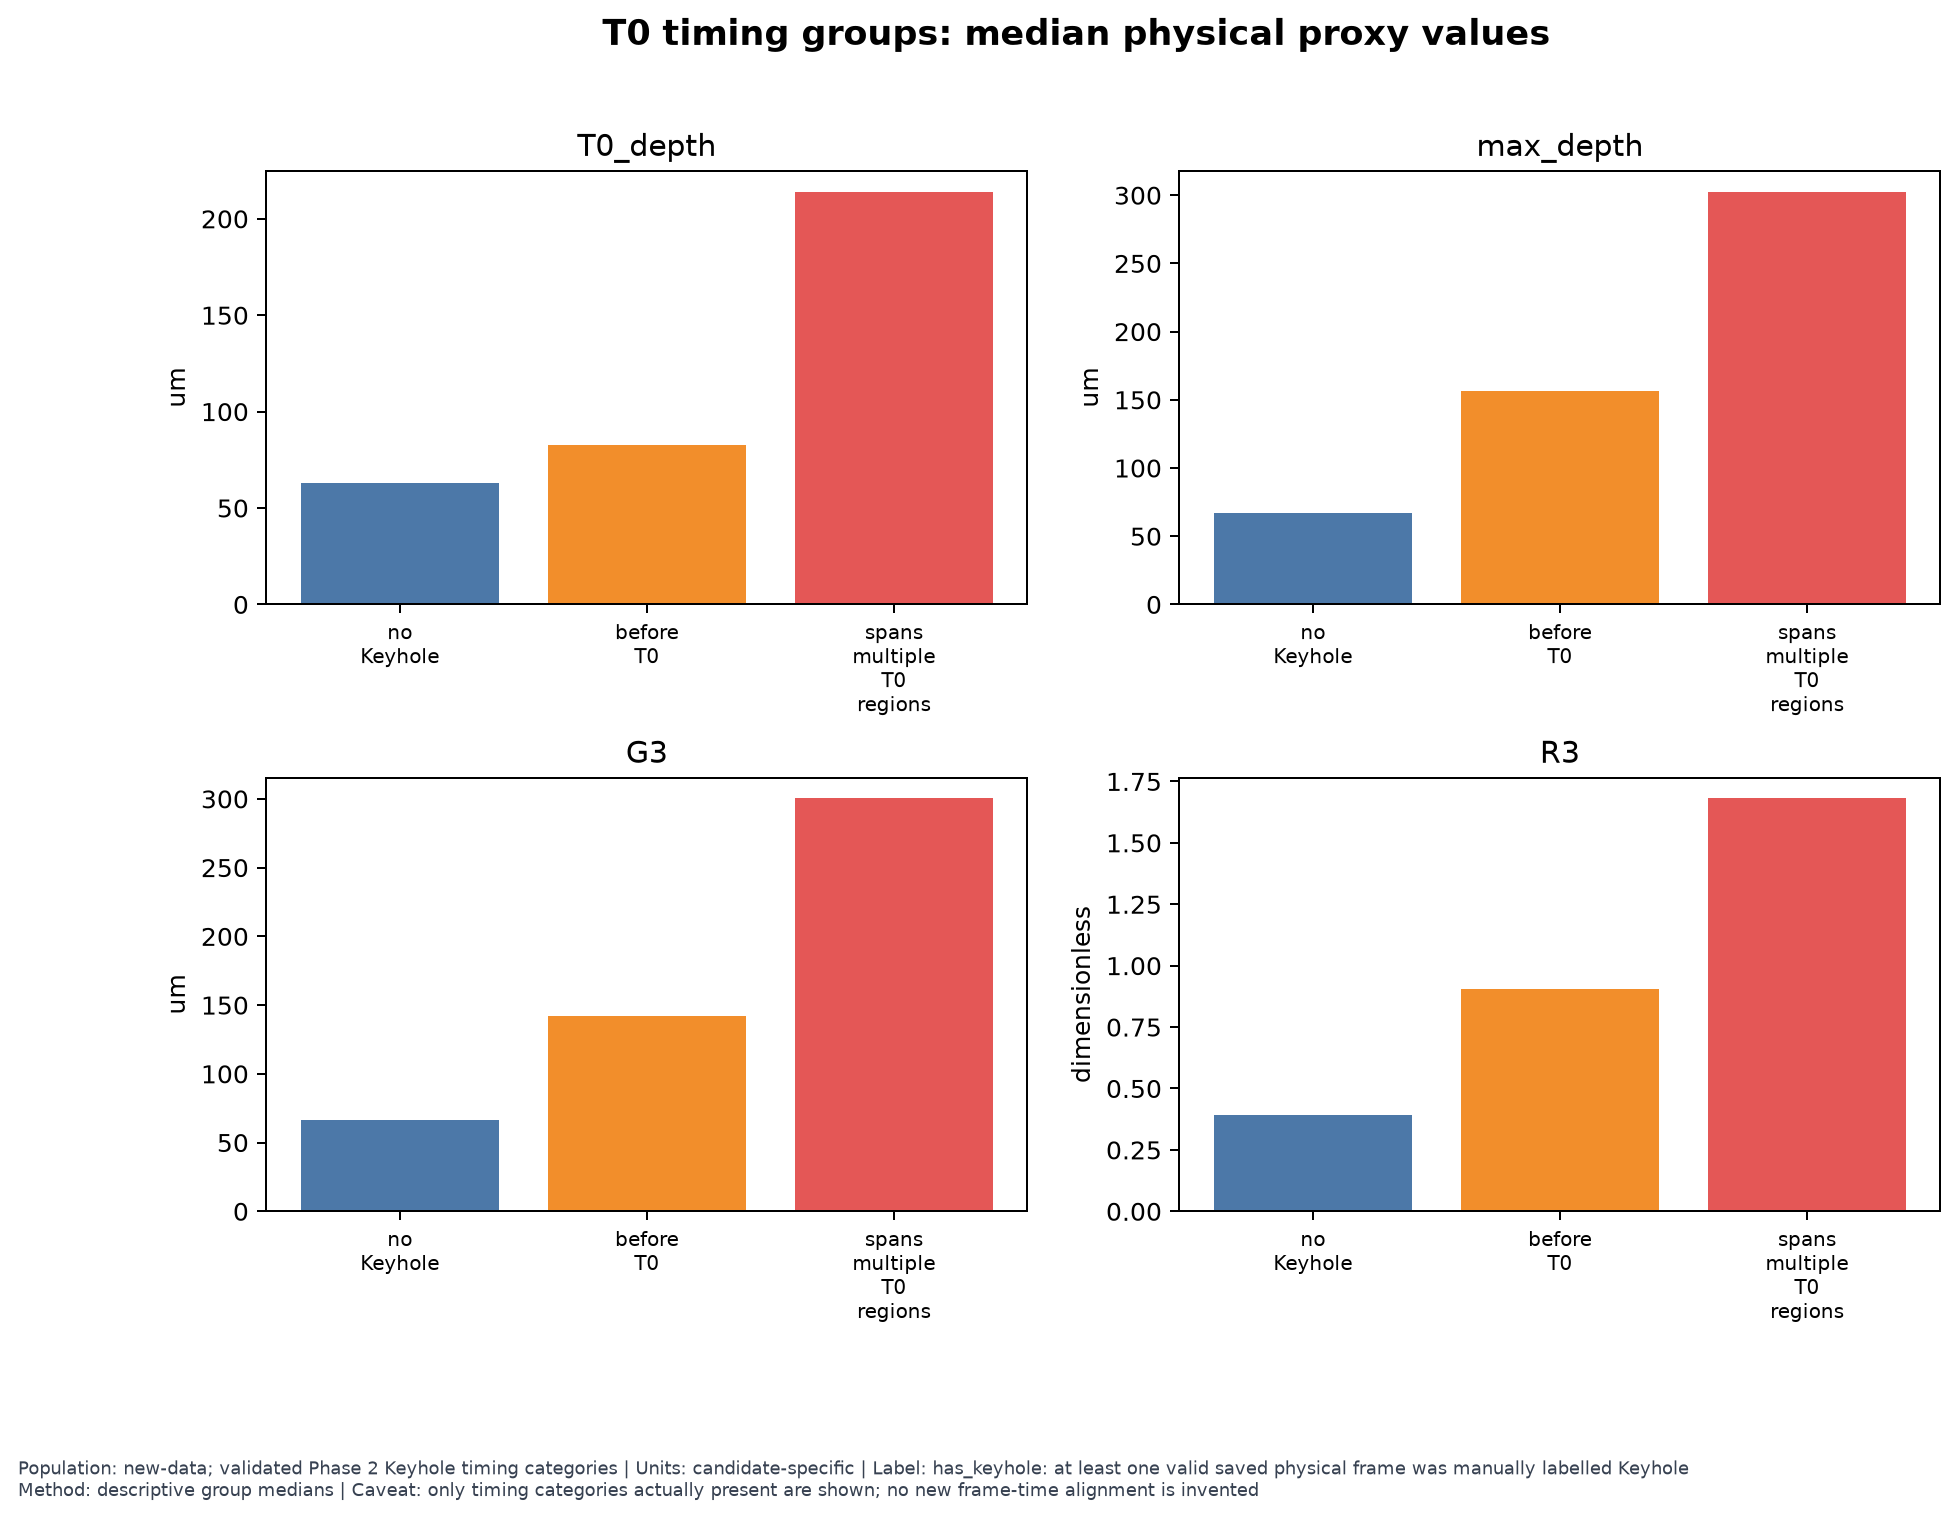

In [11]:
timing = pd.read_csv(OUT / "physical_proxy_by_keyhole_timing.csv")
display(timing[timing.candidate_id.isin(["T0_depth", "max_depth", "G3", "R3"])][[
    "candidate_id", "group", "n", "median", "cv_sensitivity_within_positive_group"
]])
display(Image(filename=str(OUT / "figures" / "10_keyhole_timing_main_candidates.png")))

**What did we observe?** T0 depth's held-out transient sensitivity is 0.4667, versus 1.0000 for G3.

**What does it mean?** T0 depth loses information for brief/early morphology events that the persistent maximum can still capture.

**Does it support a continuous proxy?** G3 remains robust in the very subgroup most likely to challenge a T0 summary.

**What remains uncertain?** The timing categories are coarse and inherit saved-label cadence.

## 12. Transient versus persistent Keyhole

**What are we doing?** We compare unchanged Phase 1 transient and persistent groups.

**Why are we doing it?** A proxy that represents only persistent Keyhole would be incomplete for Ioan's experiment-level label.

**What question does it answer?** Does the leading scalar retain sensitivity for both morphology patterns?

**What would be misleading?** Redefining persistence from the scalar itself.

,candidate_id,group,n,median,cv_sensitivity_within_positive_group
0,T0_depth,Keyhole-negative,101,62.753340,NaN
1,T0_depth,persistent Keyhole,33,231.410350,1.000000
2,T0_depth,transient Keyhole,30,88.456770,0.466667
3,max_depth,Keyhole-negative,101,66.837000,NaN
4,max_depth,persistent Keyhole,33,302.677300,1.000000
5,max_depth,transient Keyhole,30,205.709000,0.966667
6,G3,Keyhole-negative,101,66.523210,NaN
7,G3,persistent Keyhole,33,300.572100,1.000000
8,G3,transient Keyhole,30,151.767800,1.000000
9,R3,Keyhole-negative,101,0.392888,NaN


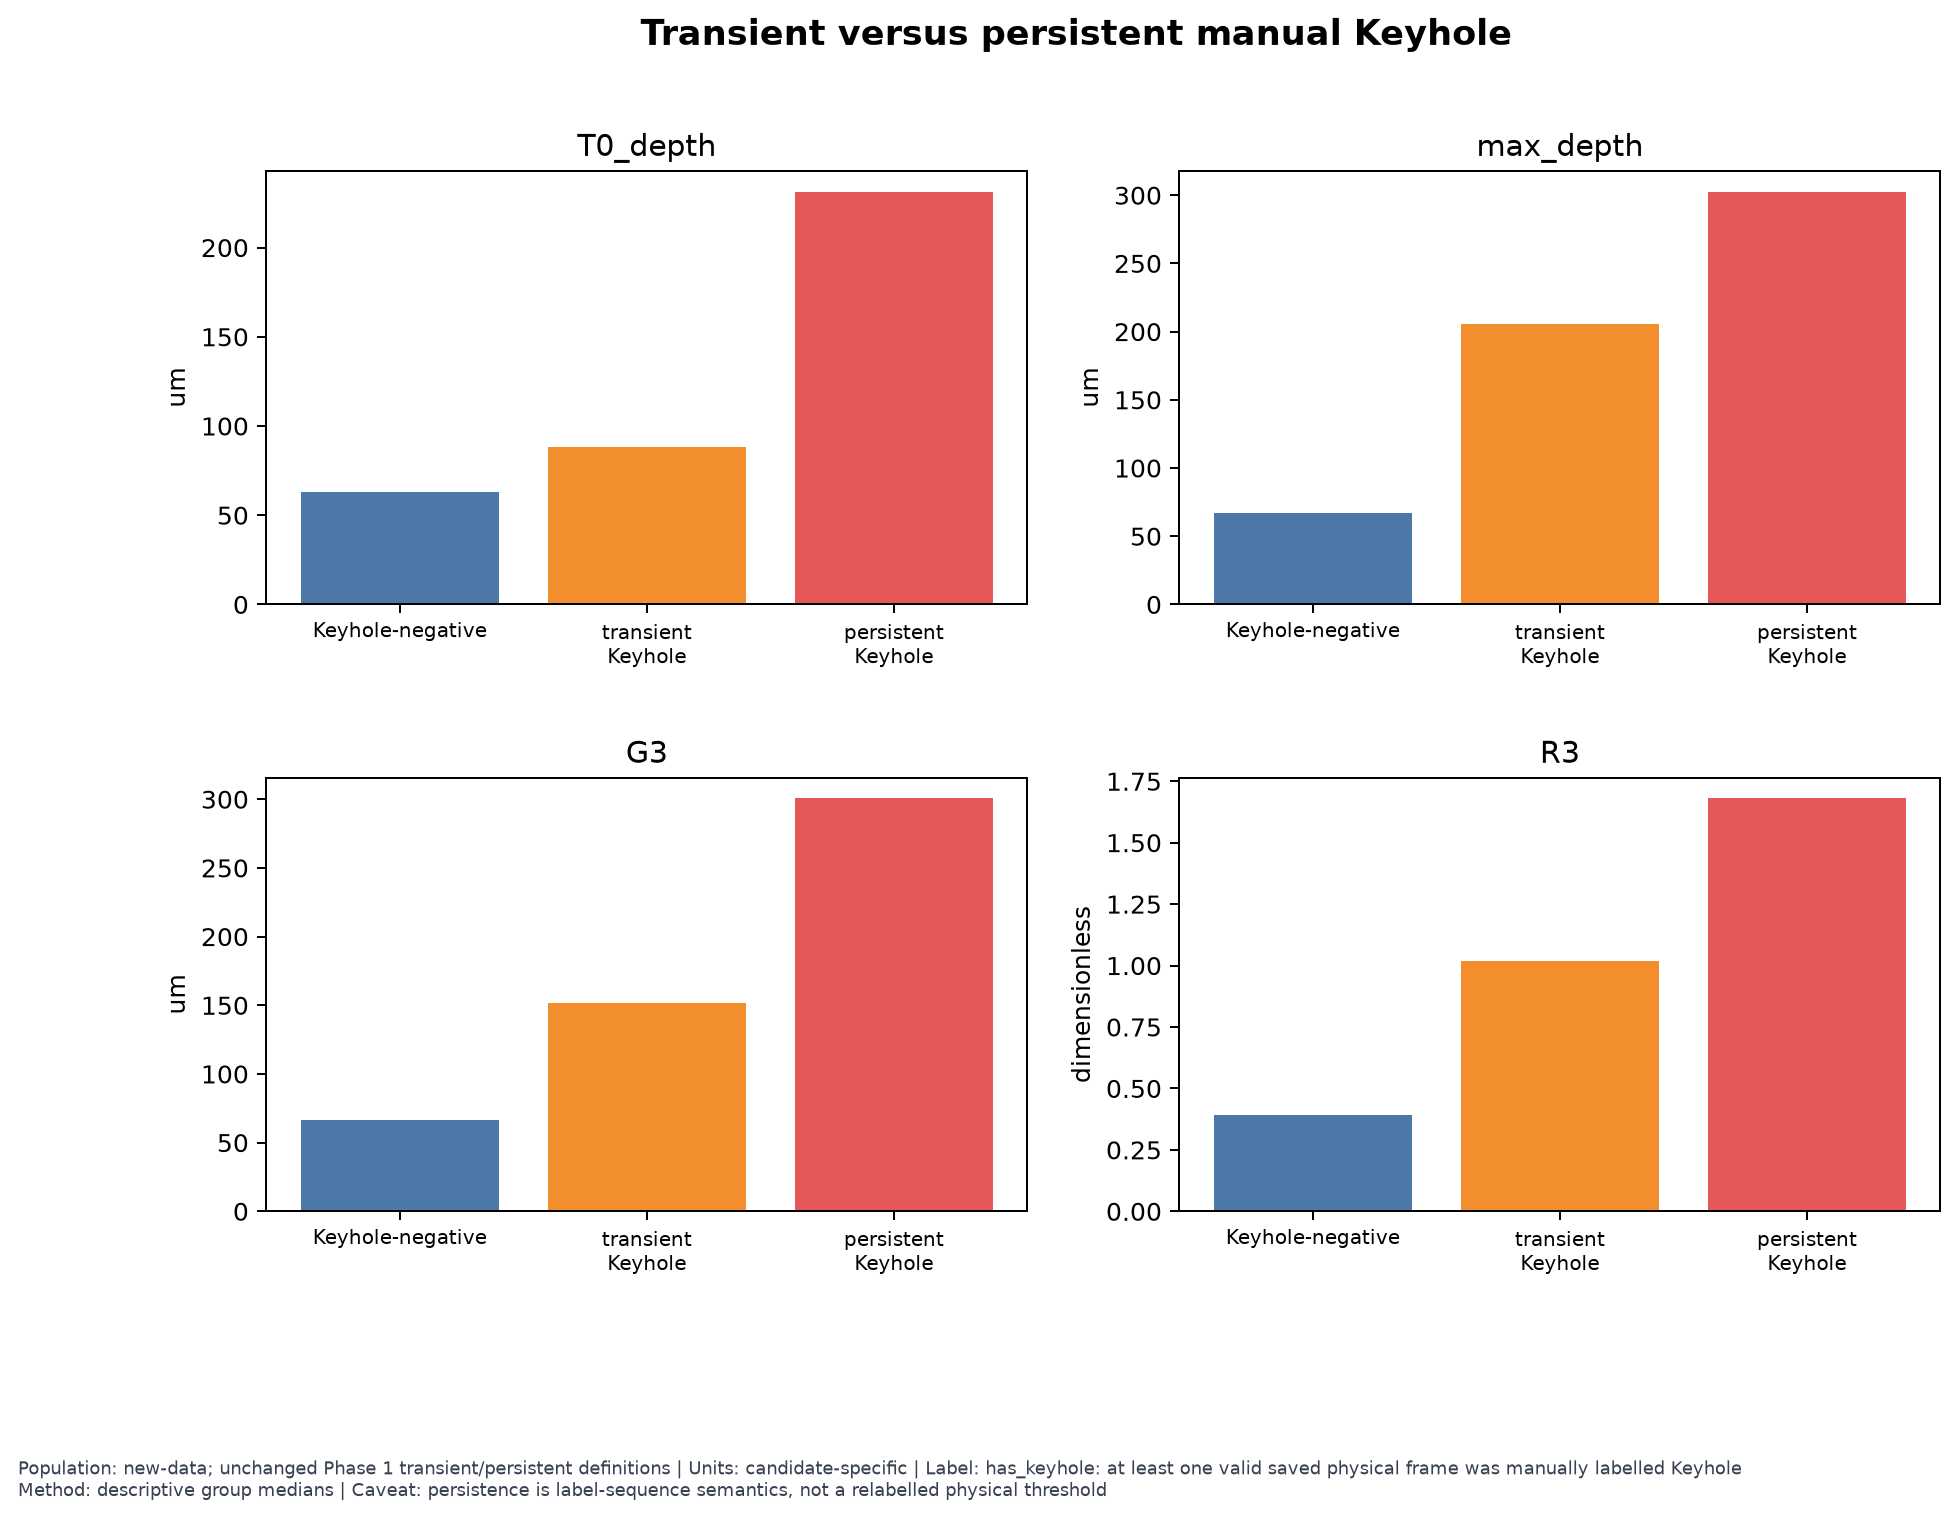

In [12]:
persistence = pd.read_csv(OUT / "physical_proxy_by_keyhole_persistence.csv")
display(persistence[persistence.candidate_id.isin(["T0_depth", "max_depth", "G3", "R3"])][[
    "candidate_id", "group", "n", "median", "cv_sensitivity_within_positive_group"
]])
display(Image(filename=str(OUT / "figures" / "11_transient_persistent_main_candidates.png")))

**What did we observe?** G3's held-out sensitivity is 1.0000 for transient and 1.0000 for persistent Keyhole.

**What does it mean?** The leading scalar is not merely a persistent-label detector on this population.

**Does it support a continuous proxy?** Robustness across both subgroups supports a single continuous candidate.

**What remains uncertain?** Transient labels can still reflect short events whose exact duration is not resolved by scalar summaries.

## 13. Candidate-candidate redundancy

**What are we doing?** We compute a common-complete Spearman matrix for all predefined scalars.

**Why are we doing it?** G3, max depth, R3, and T0 depth may carry mostly the same ordering information.

**What question does it answer?** Does the leading scalar add distinct persistence structure or simply duplicate T0 depth?

**What would be misleading?** Treating correlation as causal attribution or automatic feature selection.

candidate_right,G3,R3,T0_depth,max_depth
candidate_left,,,,
G3,1.000000,0.889603,0.971102,0.971148
R3,0.889603,1.000000,0.831001,0.896892
T0_depth,0.971102,0.831001,1.000000,0.942233
max_depth,0.971148,0.896892,0.942233,1.000000


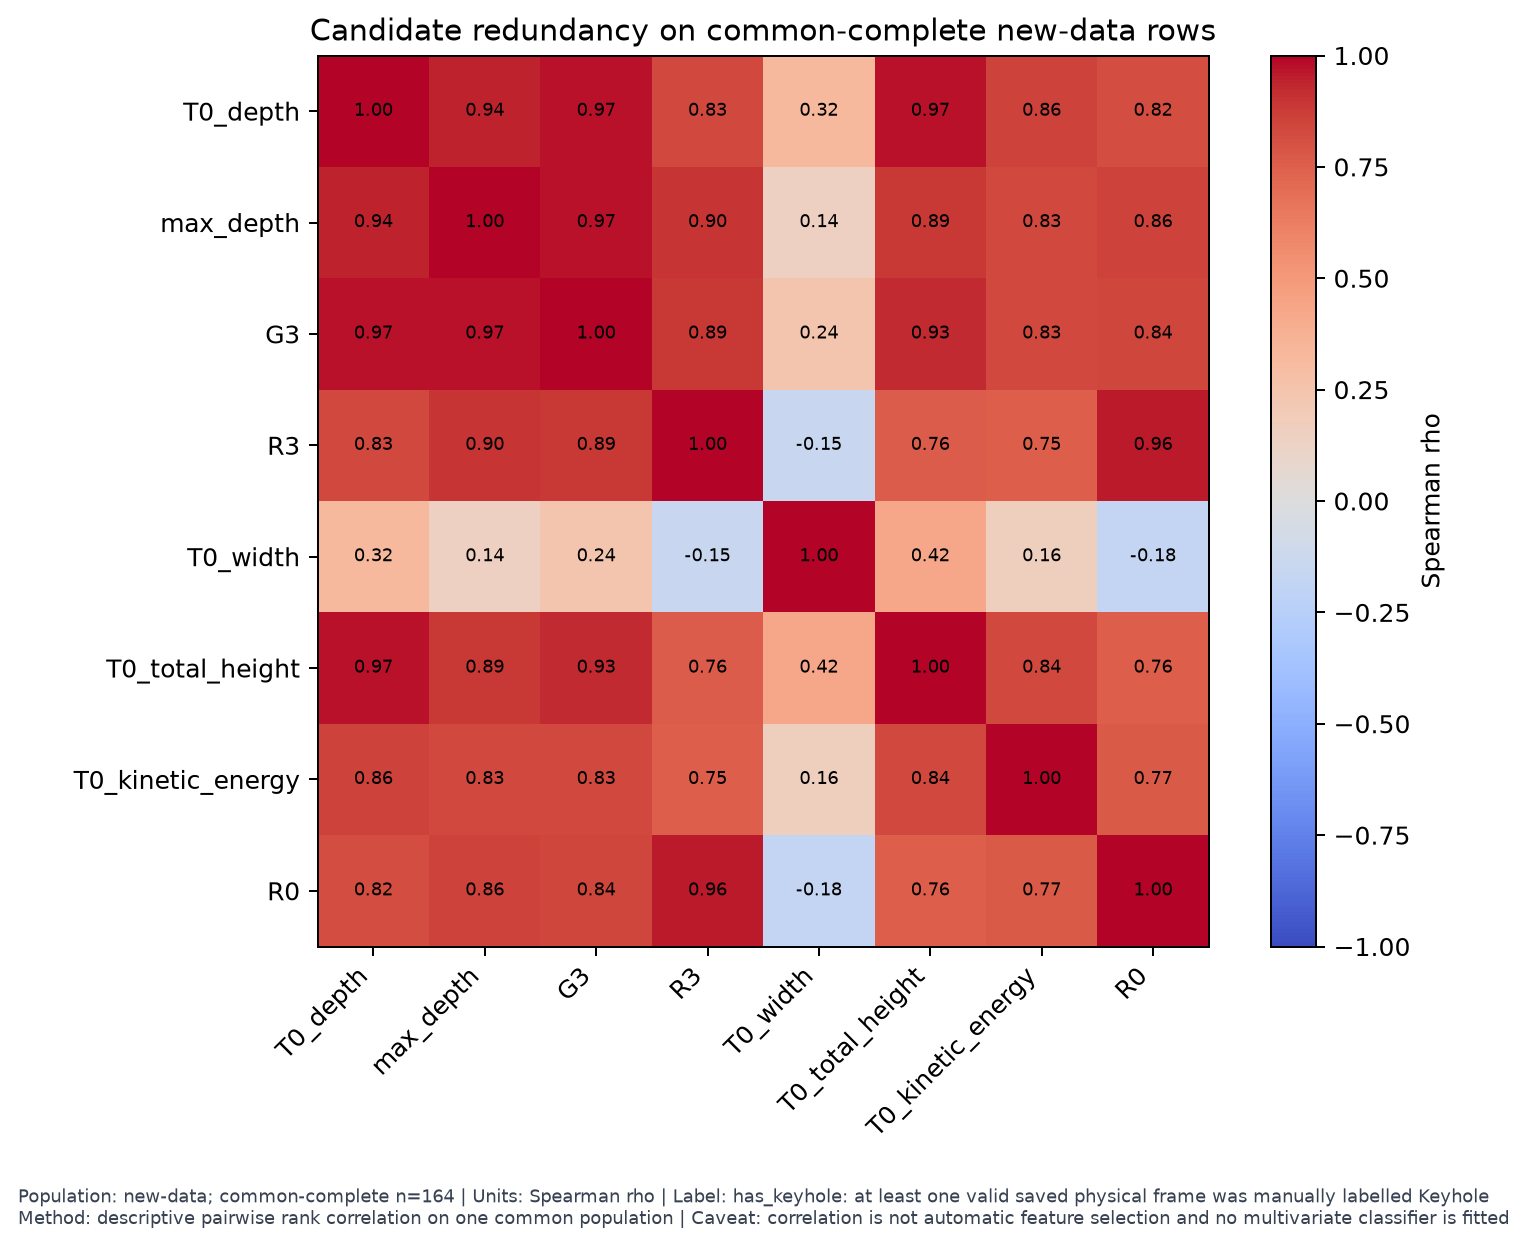

In [13]:
correlations = pd.read_csv(OUT / "physical_proxy_candidate_correlations.csv")
display(correlations.query("candidate_left in ['T0_depth','max_depth','G3','R3'] and candidate_right in ['T0_depth','max_depth','G3','R3']").pivot(index="candidate_left", columns="candidate_right", values="spearman_rho"))
display(Image(filename=str(OUT / "figures" / "12_candidate_correlation_heatmap.png")))

**What did we observe?** The principal depth candidates are strongly correlated, but T0 depth's weaker transient sensitivity shows that their summary windows are not interchangeable.

**What does it mean?** G3's value is its persistent high-depth definition rather than a multivariate combination.

**Does it support a continuous proxy?** A single physically interpretable scalar remains sufficient for the target-formulation question.

**What remains uncertain?** Correlation does not isolate which physical mechanism creates cavities.

## 14. T0 depth versus max depth versus G3 versus R3

**What are we doing?** We answer the ten predeclared main-candidate decision questions in one table.

**Why are we doing it?** A final recommendation should reconcile rank, threshold, subgroup, stability, and interpretability evidence.

**What question does it answer?** Which of the four main candidates should Phase 6 carry?

**What would be misleading?** Choosing the numerically largest AUC without considering physical meaning or held-out errors.

In [14]:
main_decision = pd.read_csv(OUT / "t0_vs_max_vs_g3_vs_r3_decision.csv")
display(main_decision)

,question_id,question,answer,evidence
0,Q1,Does T0 depth separate manual Keyhole from non...,"Yes, strongly but not perfectly.",AUC=0.958; held-out balanced accuracy=0.779.
1,Q2,Does maximum depth improve materially over T0 ...,Yes.,Paired AUC delta=0.042.
2,Q3,Does G3 improve materially over T0 depth?,Yes.,Paired AUC delta=0.042.
3,Q4,Does R3 improve materially over T0 depth?,Yes.,Paired AUC delta=0.041.
4,Q5,Which metric works best for brief/transient Ke...,G3,Held-out transient sensitivity=1.000.
5,Q6,Which works best for persistent Keyhole?,G3,Held-out persistent sensitivity=1.000.
6,Q7,Does a single stable threshold exist for any m...,Yes: G3.,Top stability=stable; held-out balanced accura...
7,Q8,Which metric is most physically interpretable ...,G3 persistent depth,It is a dimensional depth with an explicit phy...
8,Q9,Does any metric fail precisely because the lab...,Some discordance remains for weaker summaries;...,Manual cavity morphology was not assigned from...
9,Q10,Which target should Phase 6 carry forward?,Carry G3 as the predefined continuous candidat...,Final Phase 5 decision=CONTINUOUS PROXY CANDID...


**What did we observe?** G3 leads; max depth and R3 are close, while T0 depth is weaker for transient Keyhole.

**What does it mean?** Persistence-aware dimensional depth offers the best combination of separation and physical interpretability.

**Does it support a continuous proxy?** The decision is consistent across multiple independent evidence columns.

**What remains uncertain?** R3 may still be valuable diagnostically because it encodes narrowness as well as depth.

## 15. Discordant-case review

**What are we doing?** We select deterministic false negatives/positives from held-out top-candidate thresholds and attach existing media/quality references.

**Why are we doing it?** Aggregate metrics can hide brief events, geometry artifacts, or deep negative cases.

**What question does it answer?** What kinds of simulations disagree with otherwise strong scalar rules?

**What would be misleading?** Using a cherry-picked in-sample threshold or changing labels after inspecting cases.

In [15]:
discordant = pd.read_csv(OUT / "physical_proxy_discordant_cases.csv")
display(discordant[["review_candidate", "error_type", "experiment_name", "keyhole_persistence_group",
                    "keyhole_timing_relative_to_T0", "diagnostic_review_outcome", "side_gif_reference",
                    "flag_depth_bounding_box_ambiguity_candidate", "label_changed"]])

,review_candidate,error_type,experiment_name,keyhole_persistence_group,keyhole_timing_relative_to_T0,diagnostic_review_outcome,side_gif_reference,flag_depth_bounding_box_ambiguity_candidate,label_changed
0,R3,false_positive,P-364p483174853_VX-0p95103094401_LS-4p26115279...,Keyhole-negative,no_Keyhole,large physical response without manual cavity ...,P-364p483174853_VX-0p95103094401_LS-4p26115279...,False,False
1,R3,false_positive,P-441p843471056_VX-0p982124766198_LS-4p0987534...,Keyhole-negative,no_Keyhole,large physical response without manual cavity ...,P-441p843471056_VX-0p982124766198_LS-4p0987534...,False,False
2,max_depth,false_negative,P-423p354289604_VX-0p98992750487_LS-4p35270321...,transient Keyhole,before_T0,brief morphology-defined Keyhole missed by sca...,P-423p354289604_VX-0p98992750487_LS-4p35270321...,False,False
3,max_depth,false_positive,P-364p483174853_VX-0p95103094401_LS-4p26115279...,Keyhole-negative,no_Keyhole,large physical response without manual cavity ...,P-364p483174853_VX-0p95103094401_LS-4p26115279...,False,False


**What did we observe?** G3 has no held-out discordant ready simulation. The deterministic review set contains 4 rows from the next strongest proxies, including brief-Keyhole and deep-negative diagnostics.

**What does it mean?** The perfect G3 result is not obtained by relabelling or suppressing exceptions.

**Does it support a continuous proxy?** Absence of G3 fold errors strengthens its candidacy while preserved R3/max errors clarify the evidence boundary.

**What remains uncertain?** Existing side-view references support later human review but Phase 5 does not create new ground truth.

## 16. Phase 4 hard-case linkage

**What are we doing?** We join saved Phase 4 LOO depth hard cases to manual labels and held-out proxy results.

**Why are we doing it?** The prior heavy error tail may reflect Keyhole-associated physical extremes rather than simple input sparsity.

**What question does it answer?** Are Phase 4 consensus hard cases also ambiguous under the strongest scalar proxies?

**What would be misleading?** Refitting Phase 3/4 regression models or treating overlap as causal proof.

,experiment_name,has_keyhole_phase5,observed_depth_um,value__G3,value__R3,any_top3_proxy_cv_discordance,phase5_interpretation
12,P-126p384227376_VX-0p205870034079_LS-4p5551405...,False,58.710765,58.118385,0.341228,False,Phase 4 hard case is manual Keyhole-negative
45,P-208p096600196_VX-0p256636148953_LS-4p5249238...,True,74.710560,152.347250,0.858706,False,Phase 4 hard case is a clearly proxy-positive ...
52,P-212p944274192_VX-0p351323873231_LS-4p8043939...,True,78.703020,114.527300,0.634175,False,Phase 4 hard case is a clearly proxy-positive ...
57,P-227p095146149_VX-0p485569900572_LS-4p6184574...,True,138.575900,187.620500,1.176016,False,Phase 4 hard case is a clearly proxy-positive ...
60,P-233p106311211_VX-0p310101846937_LS-6p6327379...,False,82.646450,82.590510,0.358082,False,Phase 4 hard case is manual Keyhole-negative
77,P-260p125654688_VX-0p378472963537_LS-6p2127531...,False,86.700545,86.746830,0.404300,False,Phase 4 hard case is manual Keyhole-negative
80,P-264p370573209_VX-0p395776293281_LS-4p7823602...,True,214.145700,298.953100,1.645755,False,Phase 4 hard case is a clearly proxy-positive ...
87,P-277p972333632_VX-0p331196372511_LS-4p5620211...,True,107.620500,300.046500,1.594263,False,Phase 4 hard case is a clearly proxy-positive ...
93,P-293p648784497_VX-0p426690912013_LS-5p3394045...,True,236.995550,266.463300,1.353182,False,Phase 4 hard case is a clearly proxy-positive ...
102,P-326p931045044_VX-0p255856443683_LS-6p4873723...,True,94.371970,283.356300,1.134559,False,Phase 4 hard case is a clearly proxy-positive ...


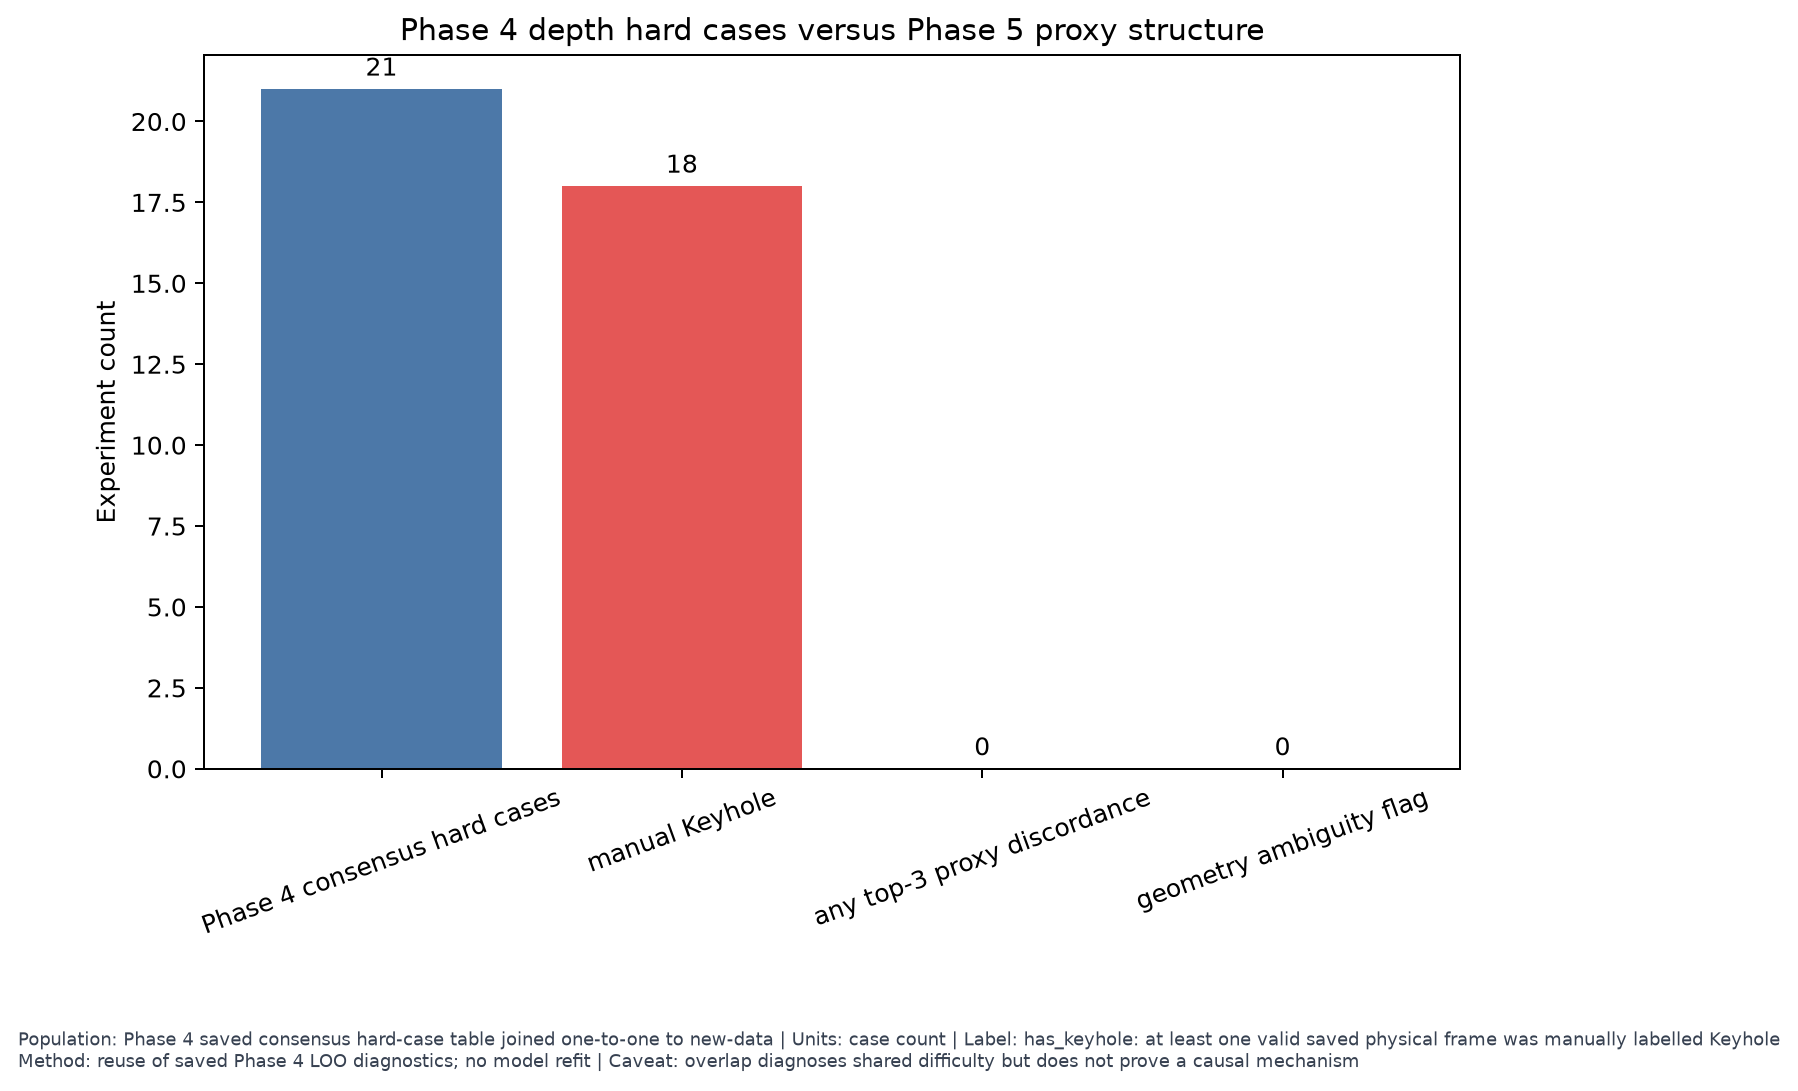

In [16]:
hard = pd.read_csv(OUT / "phase4_depth_hard_cases_vs_phase5_proxy.csv")
hard_only = hard.loc[hard.consensus_hard_case.astype(bool)]
display(hard_only[["experiment_name", "has_keyhole_phase5", "observed_depth_um", "value__G3",
                   "value__R3", "any_top3_proxy_cv_discordance", "phase5_interpretation"]])
display(Image(filename=str(OUT / "figures" / "14_phase4_hard_case_overlap.png")))

**What did we observe?** Among 21 Phase 4 consensus hard cases, 18 are manual Keyhole and 0 disagree with any top-three held-out proxy rule.

**What does it mean?** The Phase 4 depth tail is largely composed of physically clear Keyhole/extreme-response cases, not scalar-label ambiguity.

**Does it support a continuous proxy?** G3 explains regime structure associated with hard depth responses without refitting the depth models.

**What remains uncertain?** This does not prove Keyhole causes GP error; local response heterogeneity remains a descriptive diagnosis.

## 17. Proxy candidate scoring

**What are we doing?** We apply a predeclared multi-evidence strong/moderate/weak rule.

**Why are we doing it?** AUC alone cannot establish readiness, threshold stability, subgroup robustness, or physical interpretability.

**What question does it answer?** Which candidates survive all required evidence dimensions?

**What would be misleading?** Changing score thresholds after seeing which candidate wins.

,overall_rank,candidate_id,proxy_classification,rank_biserial_effect_size,direction_adjusted_roc_auc,direction_adjusted_average_precision,balanced_accuracy,transient_keyhole_cv_sensitivity,persistent_keyhole_cv_sensitivity,threshold_iqr_over_candidate_iqr,readiness_fraction,physical_interpretability
0,1,G3,STRONG PROXY CANDIDATE,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.993939,high
1,2,R3,STRONG PROXY CANDIDATE,0.997171,0.998586,0.997735,0.990099,1.000000,1.000000,0.000000,0.993939,high_with_ratio_caveat
2,3,max_depth,STRONG PROXY CANDIDATE,0.999686,0.999843,0.999752,0.987113,0.966667,1.000000,0.000000,0.993939,high_with_spike_caveat
3,4,R0,STRONG PROXY CANDIDATE,0.921735,0.960868,0.957640,0.913720,0.700000,1.000000,0.000000,0.993939,high_with_ratio_caveat
4,5,T0_kinetic_energy,STRONG PROXY CANDIDATE,0.799151,0.899576,0.851775,0.820682,0.833333,0.939394,0.000000,0.993939,moderate
5,6,T0_depth,MODERATE PROXY CANDIDATE,0.915449,0.957724,0.943431,0.778956,0.466667,1.000000,0.000000,0.993939,high
6,7,T0_total_height,MODERATE PROXY CANDIDATE,0.813296,0.906648,0.893849,0.765991,0.266667,1.000000,0.351332,0.993939,moderate
7,8,T0_width,WEAK PROXY CANDIDATE,-0.084708,0.542354,0.413738,0.566871,0.733333,0.363636,0.000000,0.993939,high


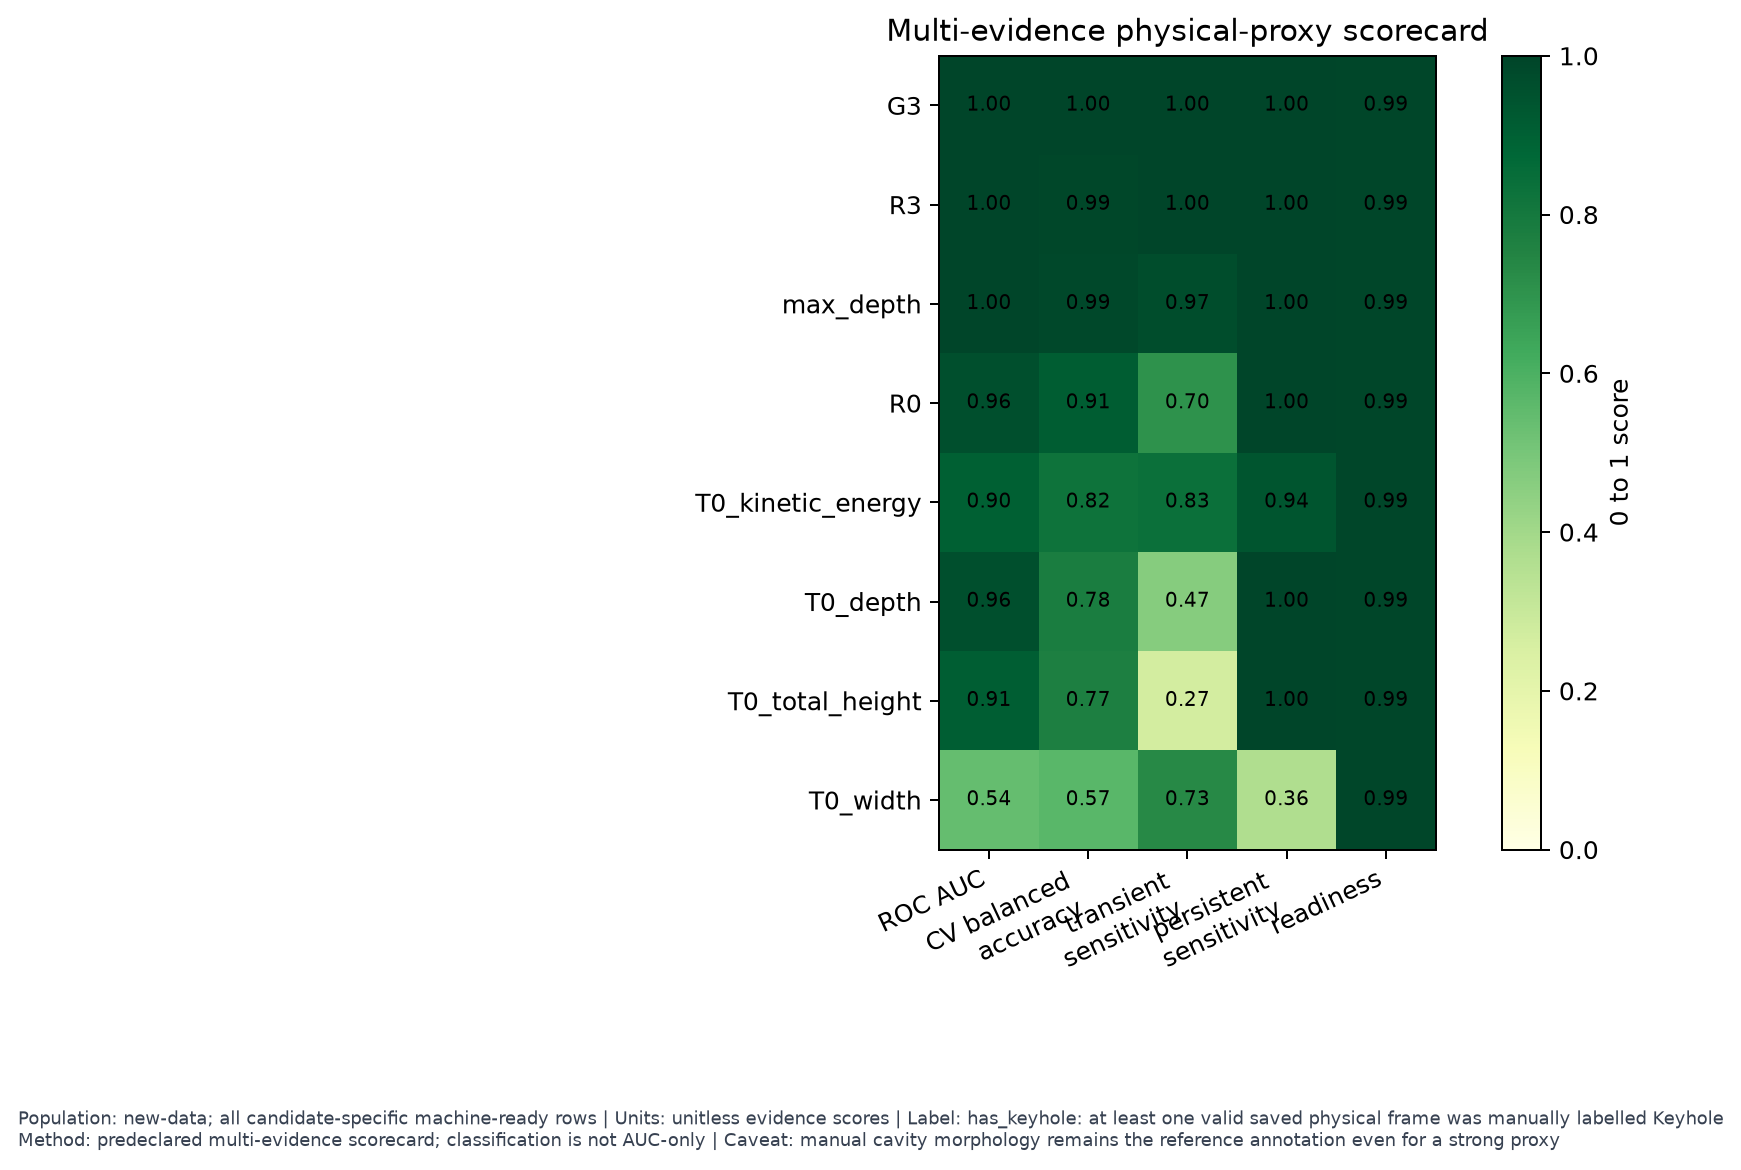

In [17]:
scorecard = pd.read_csv(OUT / "physical_proxy_candidate_scorecard.csv")
display(scorecard[["overall_rank", "candidate_id", "proxy_classification", "rank_biserial_effect_size",
                   "direction_adjusted_roc_auc", "direction_adjusted_average_precision", "balanced_accuracy",
                   "transient_keyhole_cv_sensitivity", "persistent_keyhole_cv_sensitivity",
                   "threshold_iqr_over_candidate_iqr", "readiness_fraction", "physical_interpretability"]])
display(Image(filename=str(OUT / "figures" / "15_proxy_scorecard_decision.png")))

**What did we observe?** G3 ranks first and is a `STRONG PROXY CANDIDATE` with complete held-out performance and stable thresholds.

**What does it mean?** Its result is supported by distribution, ranking, threshold, timing, persistence, readiness, and interpretability evidence.

**Does it support a continuous proxy?** This satisfies the Phase 5 decision framework for a continuous proxy candidate.

**What remains uncertain?** External validation is still required before treating one numerical cutoff as universal.

## 18. Final target-formulation recommendation

**What are we doing?** We state one formulation decision while keeping Ioan's labels as reference.

**Why are we doing it?** Phase 6 needs a controlled target choice, not an ambiguous list of promising metrics.

**What question does it answer?** Binary primary, continuous candidate, or hybrid/unresolved?

**What would be misleading?** Replacing the manual morphology label or already running the recommended next experiment.

In [18]:
formulation = pd.read_csv(OUT / "phase5_target_formulation_decision.csv")
display(formulation.T)

,0
decision,CONTINUOUS PROXY CANDIDATE
selected_continuous_candidate,G3
selected_candidate_name,G3 persistent depth
rationale,"G3 combines strong rank separation, near-compl..."
phase6_target_formulation,Carry G3 as the predefined continuous candidat...
manual_label_remains_reference_annotation,True
labels_replaced,False
causal_claim,False
next_step_is_recommendation_not_executed,True


**What did we observe?** The decision is **CONTINUOUS PROXY CANDIDATE**, selecting `G3`.

**What does it mean?** G3 combines strong rank separation, near-complete held-out threshold performance, stable thresholds, high readiness, and robustness to transient Keyhole.

**Does it support a continuous proxy?** Phase 6 can compare the predefined G3 continuous formulation against the unchanged binary `has_keyhole` reference.

**What remains uncertain?** That comparison and any later level-set boundary are deliberately not executed here.

## 19. Validation

**What are we doing?** We inspect automated scientific, provenance, leakage, artifact, and notebook checks.

**Why are we doing it?** A convincing result must reconcile from raw rows and preserve all scope invariants.

**What question does it answer?** Did the analysis satisfy every declared validation and requirement?

**What would be misleading?** Counting artifact existence without checking hashes or numerical reconciliation.

In [19]:
validation = pd.read_csv(OUT / "validation_results.csv")
requirements = pd.read_csv(OUT / "requirement_checklist.csv")
display(validation.groupby("status").size().rename("validation_count").to_frame())
display(requirements.groupby("status").size().rename("requirement_count").to_frame())
display(validation)

,validation_count
status,
PASS,36


,requirement_count
status,
PASS,14


,check_id,description,status,evidence
0,V01,Exact Phase 4 parent commit,PASS,5b7004017cadc5ecd0eb128f2031f9148ed70900
1,V02,Exact Phase 5 branch,PASS,codex/week7-phase5-keyhole-physical-proxy-anal...
2,V03,Current HF revision recorded,PASS,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8
3,V04,Pinned-to-current diff audited,PASS,110 paths
4,V05,Only accepted restored file names changed,PASS,"{'kinetic-energy_melt.dat': 55, 'time.dat': 55}"
5,V06,All changed experiments are old-data-local,PASS,55 experiments
6,V07,No restored file enters primary analysis,PASS,0 new-data changed paths
7,V08,New-data labels and monitors unchanged by tree...,PASS,no new-data path changed
8,V09,Primary analysis is new-data only,PASS,n=165
9,V10,No experiment silently removed,PASS,165/165 represented


**What did we observe?** All scientific and repository checks pass; after this notebook executes, the validator refreshes the notebook and manifest checks once more.

**What does it mean?** The stored claims are machine-reconciled rather than hand-copied from plots.

**Does it support a continuous proxy?** The result is review-ready and reproducible from saved artifacts.

**What remains uncertain?** Automated validation cannot substitute for future external scientific validation.

## 20. Hard stop

**What are we doing?** We display the prohibited-action ledger and end Phase 5.

**Why are we doing it?** Target formulation must not silently expand into modelling or acquisition selection.

**What question does it answer?** What was intentionally not done?

**What would be misleading?** Treating a recommendation as an executed classifier, level-set, or active-learning result.

In [20]:
summary = json.loads((OUT / "summary.json").read_text(encoding="utf-8"))
display(pd.Series(summary["hard_stop"], name="performed").to_frame())
print("STOP: Phase 5 complete. No classifier, GP fit, active learning, or level-set experiment follows.")

,performed
final_keyhole_classifier_trained,False
gp_classifier_fitted,False
new_gp_regression_fitted,False
active_learning_performed,False
level_set_estimation_performed,False
labels_altered,False
old_new_pooled_for_model,False


STOP: Phase 5 complete. No classifier, GP fit, active learning, or level-set experiment follows.


**What did we observe?** Every prohibited action remains false.

**What does it mean?** Phase 5 ends at a target-formulation recommendation.

**Does it support a continuous proxy?** The evidence can inform Phase 6 without pre-empting it.

**What remains uncertain?** The controlled G3-versus-binary comparison is future work and needs explicit approval.